#**Imports and setup**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')

I0000 00:00:1784822268.071730 2903871 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784822268.133411 2903871 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784822272.015006 2903871 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#**Data Loading and Datetime Parsing**

In [21]:
# Load raw training and testing data
train_df = pd.read_csv('train_raw.csv')
test_df = pd.read_csv('test_raw.csv')

# Merge train and test datasets
df = pd.concat([train_df, test_df], ignore_index=True)

# Create a proper datetime column and sort the dataset
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values(by=['station', 'date']).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (420768, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [27]:
#**Exploratory Data Analysis & Visualizations**

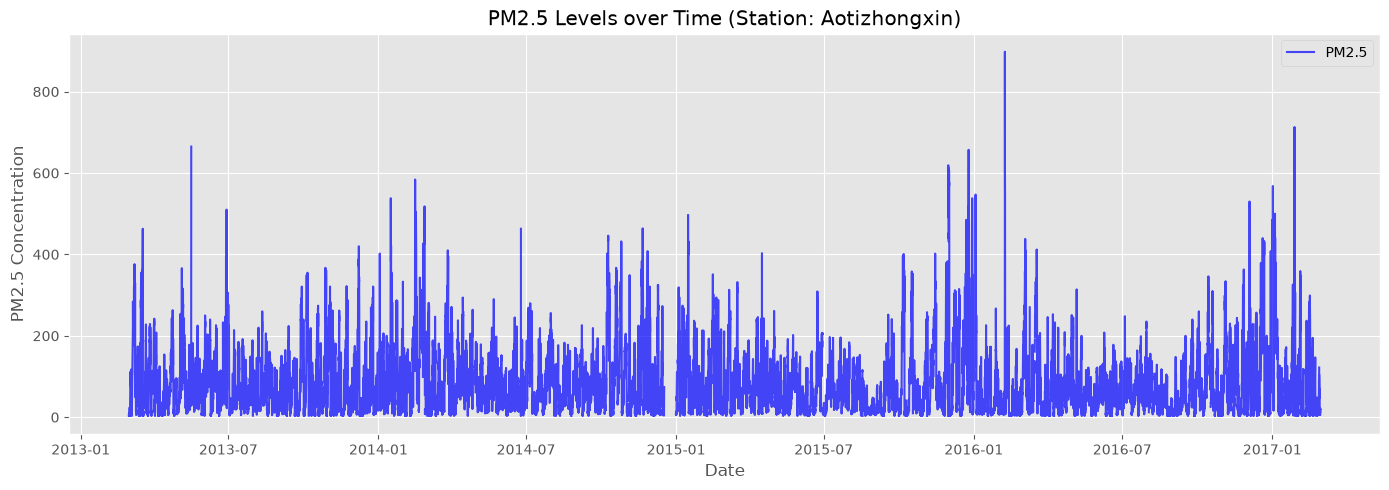

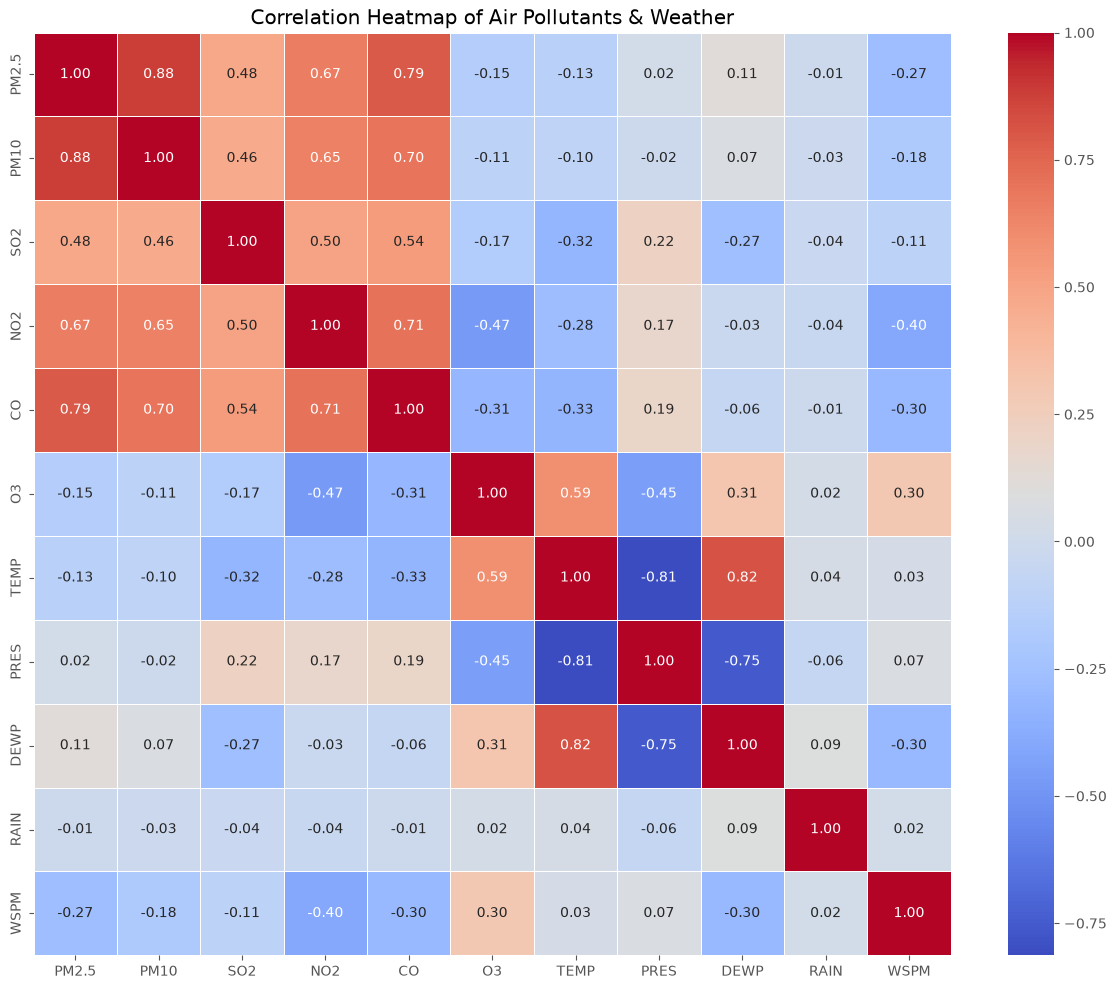

In [22]:
# 1. Plot PM2.5 Time Series for a single station (e.g., Aotizhongxin)
plt.figure(figsize=(14, 5))
sample_station = df[df['station'] == 'Aotizhongxin']
plt.plot(sample_station['date'], sample_station['PM2.5'], label='PM2.5', color='blue', alpha=0.7)
plt.title('PM2.5 Levels over Time (Station: Aotizhongxin)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (Fixed: Only using numeric columns)
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Exclude structural columns from heatmap
heatmap_cols = [c for c in numeric_cols if c not in ['No', 'year', 'month', 'day', 'hour']]

sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Air Pollutants & Weather')
plt.tight_layout()
plt.show()

In [29]:
#**Station-Aware Missing Value Imputation**

In [23]:
# Group by station to prevent cross-contamination during imputation
def impute_missing(group):
    # Interpolate forward, then backward fill remaining NaNs at the start
    return group.interpolate(method='linear', limit_direction='forward').bfill()

# Apply the imputation station by station
df = df.groupby('station', group_keys=False).apply(impute_missing)

# Check to ensure no missing values remain
print("Missing values after station-aware imputation:")
print(df.isnull().sum())

Missing values after station-aware imputation:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
date       0
dtype: int64


In [31]:
#**Feature Engineering**

In [24]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

# -----------------------------------------------------
# 1. PM2.5 Lag Features
# -----------------------------------------------------
lags = [1, 2, 3, 6, 12, 24]

for lag in lags:
    df[f'PM25_lag_{lag}'] = (
        df.groupby('station')['PM2.5'].shift(lag)
    )


# -----------------------------------------------------
# 2. Rolling Statistics
# -----------------------------------------------------
windows = [3, 6, 12, 24]

for w in windows:

    df[f'PM25_roll_mean_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(lambda x: x.rolling(window=w).mean())
    )

    df[f'PM25_roll_std_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(lambda x: x.rolling(window=w).std())
    )


# -----------------------------------------------------
# 3. Difference Features
# -----------------------------------------------------
df['PM25_diff1'] = (
    df.groupby('station')['PM2.5'].diff(1)
)

df['PM25_diff24'] = (
    df.groupby('station')['PM2.5'].diff(24)
)


# -----------------------------------------------------
# 4. Fill NaNs Created by Lag/Rolling/Diff
# -----------------------------------------------------
df = df.groupby('station', group_keys=False).apply(
    lambda x: x.bfill().ffill()
)


# -----------------------------------------------------
# 5. Cyclic Time Features
# -----------------------------------------------------
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 23)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 23)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['weekday'] = df['date'].dt.weekday

df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)


# -----------------------------------------------------
# 6. Wind Direction Encoding
# -----------------------------------------------------
df['wd'] = df['wd'].ffill().bfill()

wd_map = {
    'N': 0,
    'NNE': 22.5,
    'NE': 45,
    'ENE': 67.5,
    'E': 90,
    'ESE': 112.5,
    'SE': 135,
    'SSE': 157.5,
    'S': 180,
    'SSW': 202.5,
    'SW': 225,
    'WSW': 247.5,
    'W': 270,
    'WNW': 292.5,
    'NW': 315,
    'NNW': 337.5
}

df['wd_angle'] = df['wd'].map(wd_map)

df['wd_sin'] = np.sin(np.radians(df['wd_angle']))
df['wd_cos'] = np.cos(np.radians(df['wd_angle']))


# -----------------------------------------------------
# 7. Station One-Hot Encoding
# -----------------------------------------------------
station_dummies = pd.get_dummies(
    df['station'],
    prefix='station',
    dtype=float
)

df = pd.concat([df, station_dummies], axis=1)

station_cols = [
    col for col in df.columns
    if col.startswith('station_')
]


# -----------------------------------------------------
# 8. Feature Lists
# -----------------------------------------------------
base_features = [
    'PM2.5',
    'PM10',
    'SO2',
    'NO2',
    'CO',
    'O3',
    'TEMP',
    'PRES',
    'DEWP',
    'RAIN',
    'WSPM'
]

lag_features = [
    f'PM25_lag_{lag}'
    for lag in lags
]

rolling_features = []

for w in windows:
    rolling_features.append(f'PM25_roll_mean_{w}')
    rolling_features.append(f'PM25_roll_std_{w}')

diff_features = [
    'PM25_diff1',
    'PM25_diff24'
]

wind_features = [
    'wd_sin',
    'wd_cos'
]

time_features = [
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'weekday_sin',
    'weekday_cos'
]


# -----------------------------------------------------
# 9. Final Feature List
# -----------------------------------------------------
all_features = (
    base_features +
    lag_features +
    rolling_features +
    diff_features +
    wind_features +
    station_cols +
    time_features
)

target = 'PM2.5'

print(f"Total Features: {len(all_features)}")
print(all_features)

Total Features: 47
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'PM25_lag_1', 'PM25_lag_2', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24', 'PM25_roll_mean_3', 'PM25_roll_std_3', 'PM25_roll_mean_6', 'PM25_roll_std_6', 'PM25_roll_mean_12', 'PM25_roll_std_12', 'PM25_roll_mean_24', 'PM25_roll_std_24', 'PM25_diff1', 'PM25_diff24', 'wd_sin', 'wd_cos', 'station_Aotizhongxin', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [33]:
#**Chronological Train & Validation Split**

In [25]:
split_date = '2016-03-01'

train_df = df[df['date'] < split_date].copy()
val_df = df[df['date'] >= split_date].copy()

print("Training:")
print(train_df['date'].min(), "to", train_df['date'].max())

print("\nValidation:")
print(val_df['date'].min(), "to", val_df['date'].max())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(val_df))

Training:
2013-03-01 00:00:00 to 2016-02-29 23:00:00

Validation:
2016-03-01 00:00:00 to 2017-02-28 23:00:00

Rows:
Train: 315648
Validation: 105120


In [35]:
#**Scaling and Target Transformation**

In [26]:
# Initialize Scalers
feature_scaler = MinMaxScaler()
# We need a separate scaler for the target so we can inverse_transform later
target_scaler = MinMaxScaler()

# ❌ REMOVED: np.log1p() transformations completely.

# Fit scalers on TRAINING data only
train_df[all_features] = feature_scaler.fit_transform(train_df[all_features])

# ✅ Scale the RAW PM2.5 target directly
train_df[['PM2.5_scaled']] = target_scaler.fit_transform(train_df[['PM2.5']])

# Transform VALIDATION data
val_df[all_features] = feature_scaler.transform(val_df[all_features])
val_df[['PM2.5_scaled']] = target_scaler.transform(val_df[['PM2.5']])

In [37]:
#**24-Hour Sequence Generation**

In [27]:
def create_sequences_per_station(data, feature_cols, target_col, window_size=24):
    X, y = [], []
    # Group by station to ensure windows don't cross station boundaries
    for station_name, group in data.groupby('station'):
        group_features = group[feature_cols].values
        group_target = group[target_col].values

        for i in range(len(group) - window_size):
            X.append(group_features[i : i + window_size])
            y.append(group_target[i + window_size])

    return np.array(X), np.array(y)

window_size = 24 #72

# Create Train Sequences
print("Generating training sequences...")
X_train, y_train = create_sequences_per_station(
    train_df,
    feature_cols=all_features,
    target_col='PM2.5_scaled', #PM2.5_log_scaled
    window_size=window_size
)

# Create Validation Sequences
print("Generating validation sequences...")
X_val, y_val = create_sequences_per_station(
    val_df,
    feature_cols=all_features,
    target_col='PM2.5_scaled',
    window_size=window_size
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

Generating training sequences...
Generating validation sequences...
X_train shape: (315360, 24, 47)
y_train shape: (315360,)
X_val shape: (104832, 24, 47)
y_val shape: (104832,)


In [39]:
#**LSTM model**

In [28]:
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization

lstm_model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    keras.layers.Bidirectional(
        keras.layers.LSTM(256, return_sequences=True)
    ),
    BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True)
    ),
    BatchNormalization(),
    keras.layers.Dropout(0.15),

    keras.layers.Bidirectional(
        keras.layers.LSTM(64)
    ),
    BatchNormalization(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(64, activation="relu"),

    keras.layers.Dense(1)
])

lstm_model.summary()

optimizer = keras.optimizers.Adam(learning_rate=5e-4)

lstm_model.compile(
    optimizer=optimizer,
    loss="mse",   # Try MSE for lower RMSE
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.R2Score(name="r2")
    ]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 24, 512)        │       622,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 24, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,471,745 (5.61 MB)

 Trainable params: 1,469,953 (5.61 MB)

 Non-trainable params: 1,792 (7.00 KB)

Training LSTM model...
Epoch 1/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - loss: 0.0085 - r2: -0.3139 - rmse: 0.0925 - val_loss: 0.0011 - val_r2: 0.8466 - val_rmse: 0.0324 - learning_rate: 5.0000e-04
Epoch 2/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 0.0012 - r2: 0.8212 - rmse: 0.0341 - val_loss: 6.2413e-04 - val_r2: 0.9091 - val_rmse: 0.0250 - learning_rate: 5.0000e-04
Epoch 3/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 7.6325e-04 - r2: 0.8827 - rmse: 0.0276 - val_loss: 4.7230e-04 - val_r2: 0.9312 - val_rmse: 0.0217 - learning_rate: 5.0000e-04
Epoch 4/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 6.0517e-04 - r2: 0.9070 - rmse: 0.0246 - val_loss: 4.4842e-04 - val_r2: 0.9347 - val_rmse: 0.0212 - learning_rate: 5.0000e-04
Epoch 5/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 5.2012e-04 - r2: 0.9201 - rmse: 0.0228 - val_loss: 3.7038e-04 - val_r2: 0.9460 - val_rmse: 0.0192 - learning_rate: 5.0000e-04
Epoch 6/100
1232/1232 ━━━━━━━━━━━

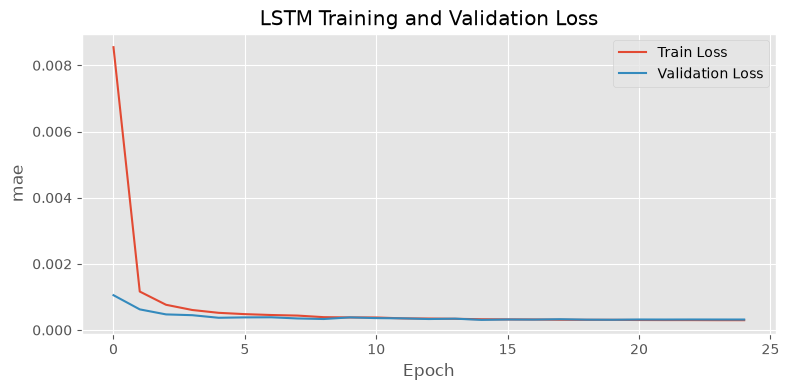

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the LSTM model
print("Training LSTM model...")

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=256,          # Try 64 if GPU memory allows
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('mae')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
from tensorflow.keras.layers import BatchNormalization

gru_model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    keras.layers.Bidirectional(
        keras.layers.GRU(128, return_sequences=True)
    ),
    BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Bidirectional(
        keras.layers.GRU(64)
    ),
    BatchNormalization(),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1)
])

gru_model.summary()

gru_model.compile(
    optimizer="adam",
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.R2Score(name="r2")
    ]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_9 (Bidirectional) │ (None, 24, 256)        │       135,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 128)            │       123,648 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,441 (1.03 MB)

 Trainable params: 268,673 (1.02 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the GRU model
print("Training GRU model...")

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.legend()

plt.tight_layout()
plt.show()

Training GRU model...
Epoch 1/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0146 - r2: -3.7400 - rmse: 0.1756 - val_loss: 5.8888e-04 - val_r2: 0.8284 - val_rmse: 0.0343 - learning_rate: 0.0010
Epoch 2/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 6.7412e-04 - r2: 0.7928 - rmse: 0.0367 - val_loss: 3.5141e-04 - val_r2: 0.8976 - val_rmse: 0.0265 - learning_rate: 0.0010
Epoch 3/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 4.4603e-04 - r2: 0.8629 - rmse: 0.0299 - val_loss: 2.5833e-04 - val_r2: 0.9247 - val_rmse: 0.0227 - learning_rate: 0.0010
Epoch 4/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 3.5151e-04 - r2: 0.8919 - rmse: 0.0265 - val_loss: 1.9824e-04 - val_r2: 0.9422 - val_rmse: 0.0199 - learning_rate: 0.0010
Epoch 5/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 3.0582e-04 - r2: 0.9060 - rmse: 0.0247 - val_loss: 2.2060e-04 - val_r2: 0.9357 - val_rmse: 0.0210 - learning_rate: 0.0010
Epoch 6/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 16s

Training GRU model...
Epoch 1/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - loss: 0.0149 - r2: -3.8123 - rmse: 0.1769 - val_loss: 6.1511e-04 - val_r2: 0.8207 - val_rmse: 0.0351 - learning_rate: 0.0010
Epoch 2/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 6.6197e-04 - r2: 0.7965 - rmse: 0.0364 - val_loss: 3.1290e-04 - val_r2: 0.9088 - val_rmse: 0.0250 - learning_rate: 0.0010
Epoch 3/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 4.1566e-04 - r2: 0.8722 - rmse: 0.0288 - val_loss: 2.5283e-04 - val_r2: 0.9263 - val_rmse: 0.0225 - learning_rate: 0.0010
Epoch 4/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 3.3179e-04 - r2: 0.8980 - rmse: 0.0258 - val_loss: 1.8093e-04 - val_r2: 0.9473 - val_rmse: 0.0190 - learning_rate: 0.0010
Epoch 5/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 2.9160e-04 - r2: 0.9104 - rmse: 0.0241 - val_loss: 1.9580e-04 - val_r2: 0.9429 - val_rmse: 0.0198 - learning_rate: 0.0010
Epoch 6/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 20s

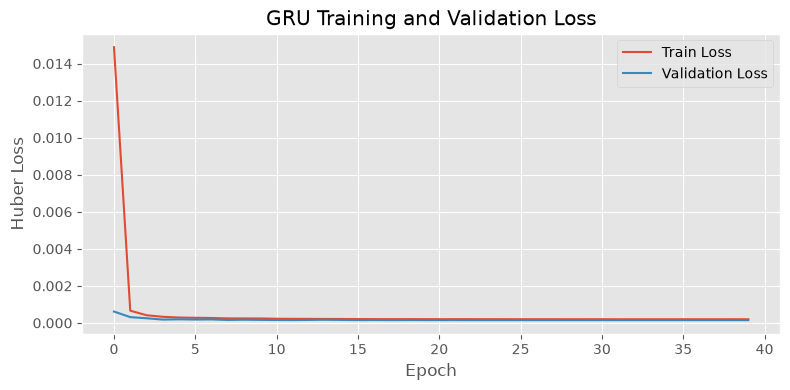

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the GRU model
print("Training GRU model...")

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.legend()

plt.tight_layout()
plt.show()

Generating LSTM predictions...
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Generating GRU predictions...
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Calculating averaged ensemble predictions...
--- LSTM Model Performance ---
RMSE: 0.0175
MAE:  0.0097
R2:   0.9554

--- GRU Model Performance ---
RMSE: 0.0172
MAE:  0.0094
R2:   0.9567

--- Averaged Ensemble Model Performance ---
RMSE: 0.0172
MAE:  0.0093
R2:   0.9571



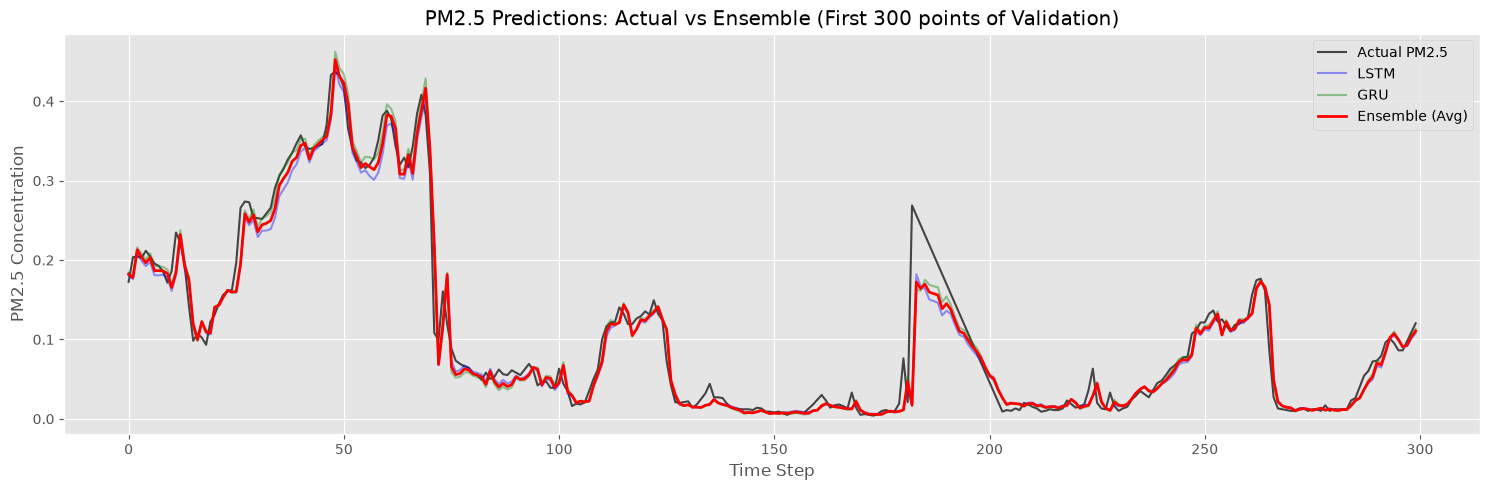

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Generate predictions for both models separately
print("Generating LSTM predictions...")
lstm_preds_scaled = lstm_model.predict(X_val, batch_size=256)

print("Generating GRU predictions...")
gru_preds_scaled = gru_model.predict(X_val, batch_size=256)

# 2. Average the predictions (Ensemble approach)
print("Calculating averaged ensemble predictions...")
ensemble_preds_scaled = (lstm_preds_scaled + gru_preds_scaled) / 2.0

# 3. Inverse transform predictions back to the original PM2.5 scale
# The scaler expects a 2D array, so we ensure the predictions are reshaped correctly
lstm_preds = target_scaler.inverse_transform(lstm_preds_scaled)
gru_preds = target_scaler.inverse_transform(gru_preds_scaled)
ensemble_preds = target_scaler.inverse_transform(ensemble_preds_scaled)

# Inverse transform the actual validation targets for accurate metric calculation
y_val_actual = target_scaler.inverse_transform(y_val.reshape(-1, 1))

# 4. Evaluate and compare the models
def evaluate_preds(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}\n")

evaluate_preds(y_val_actual, lstm_preds, "LSTM Model")
evaluate_preds(y_val_actual, gru_preds, "GRU Model")
evaluate_preds(y_val_actual, ensemble_preds, "Averaged Ensemble Model")

# 5. Optional: Plot a small window to visualize the ensemble vs actuals
plt.figure(figsize=(15, 5))
# Plotting just the first 300 points for clarity
plot_window = 300 
plt.plot(y_val_actual[:plot_window], label='Actual PM2.5', color='black', alpha=0.7)
plt.plot(lstm_preds[:plot_window], label='LSTM', color='blue', alpha=0.4)
plt.plot(gru_preds[:plot_window], label='GRU', color='green', alpha=0.4)
plt.plot(ensemble_preds[:plot_window], label='Ensemble (Avg)', color='red', linewidth=2)

plt.title('PM2.5 Predictions: Actual vs Ensemble (First 300 points of Validation)')
plt.xlabel('Time Step')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.tight_layout()
plt.show()

--------------------------------------------------
Station: Aotizhongxin
  LSTM RMSE:     0.0171
  GRU RMSE:      0.0168
  Ensemble RMSE: 0.0167
--------------------------------------------------


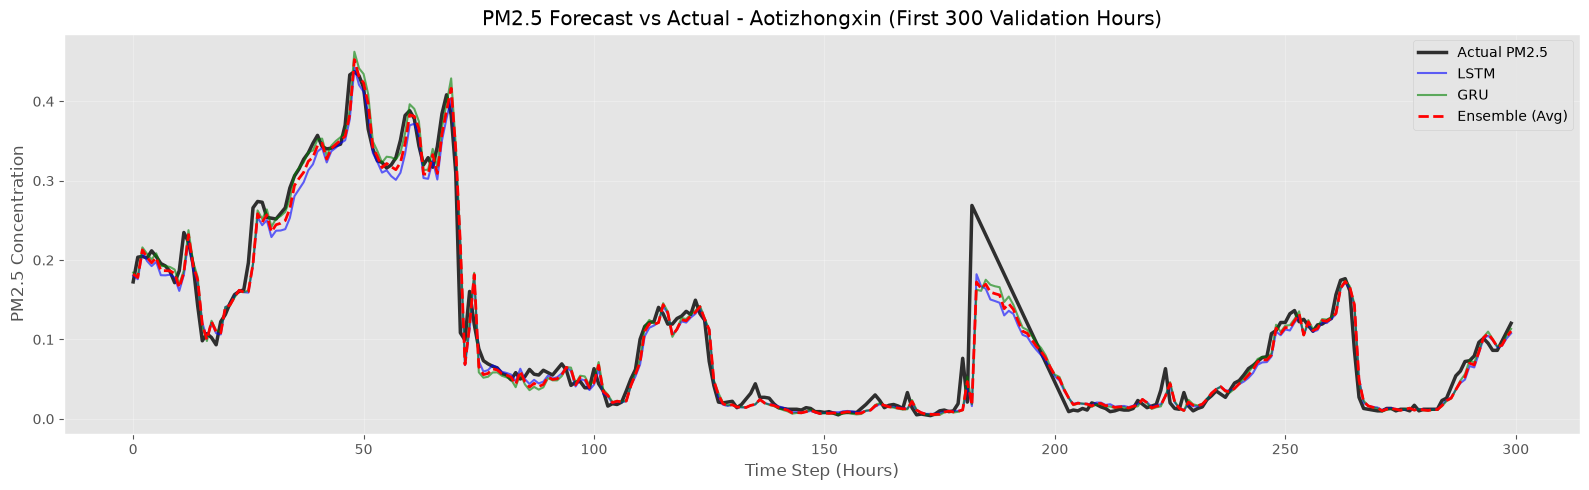

--------------------------------------------------
Station: Changping
  LSTM RMSE:     0.0163
  GRU RMSE:      0.0162
  Ensemble RMSE: 0.0161
--------------------------------------------------


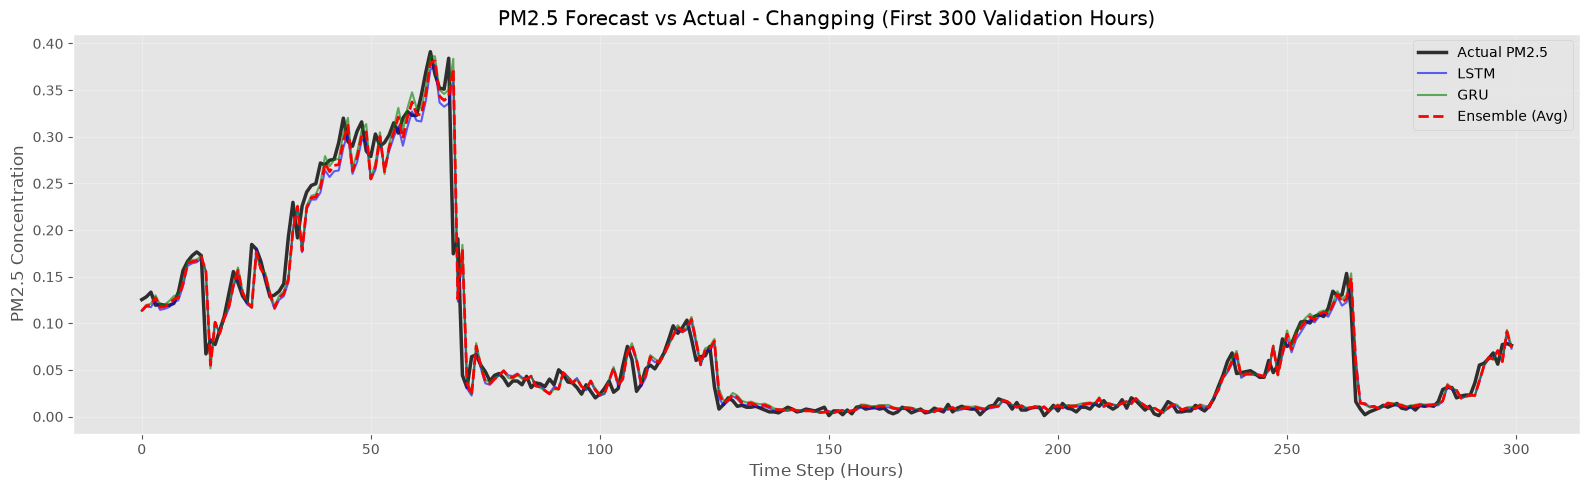

--------------------------------------------------
Station: Dingling
  LSTM RMSE:     0.0168
  GRU RMSE:      0.0166
  Ensemble RMSE: 0.0166
--------------------------------------------------


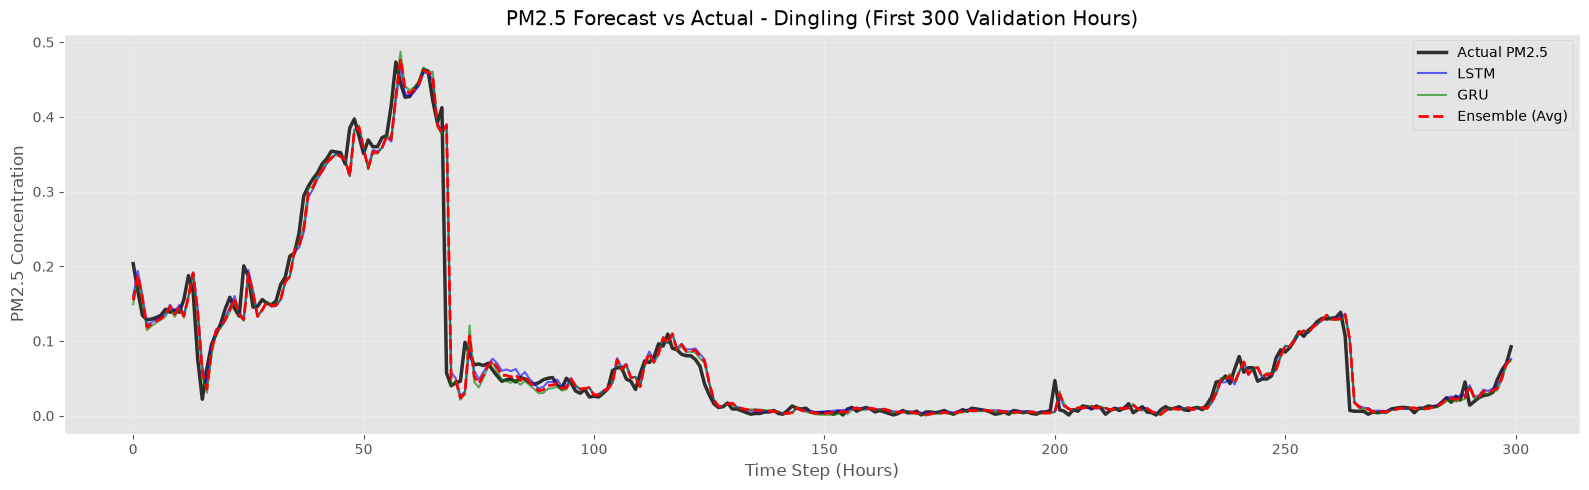

--------------------------------------------------
Station: Dongsi
  LSTM RMSE:     0.0193
  GRU RMSE:      0.0190
  Ensemble RMSE: 0.0189
--------------------------------------------------


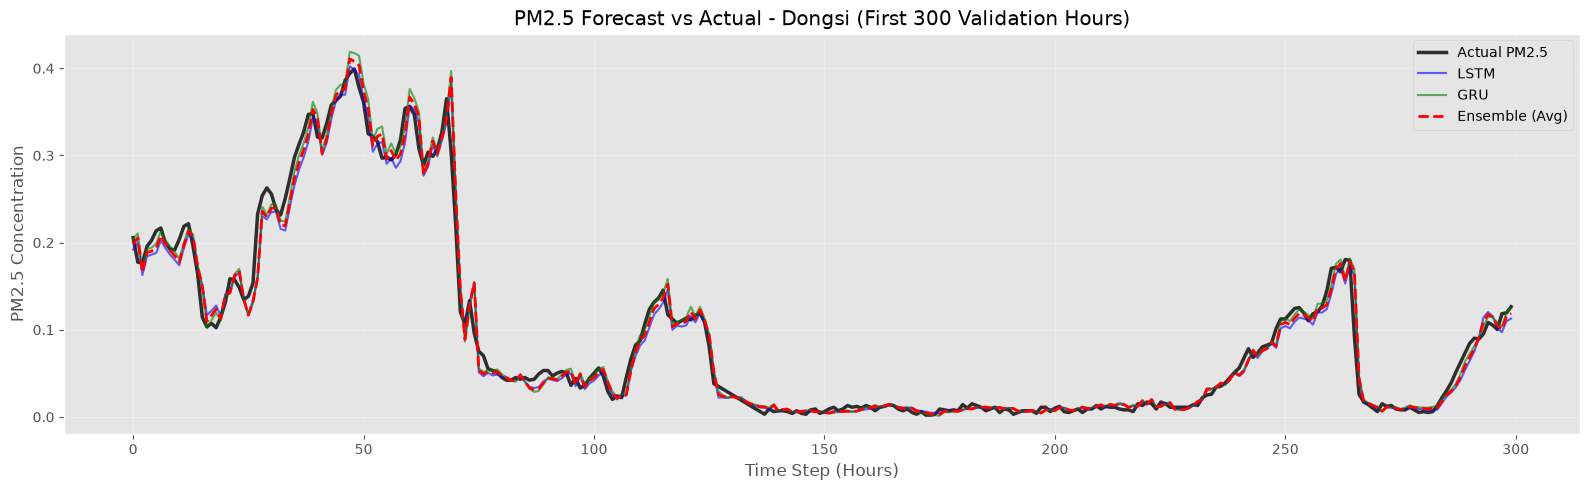

--------------------------------------------------
Station: Guanyuan
  LSTM RMSE:     0.0179
  GRU RMSE:      0.0172
  Ensemble RMSE: 0.0172
--------------------------------------------------


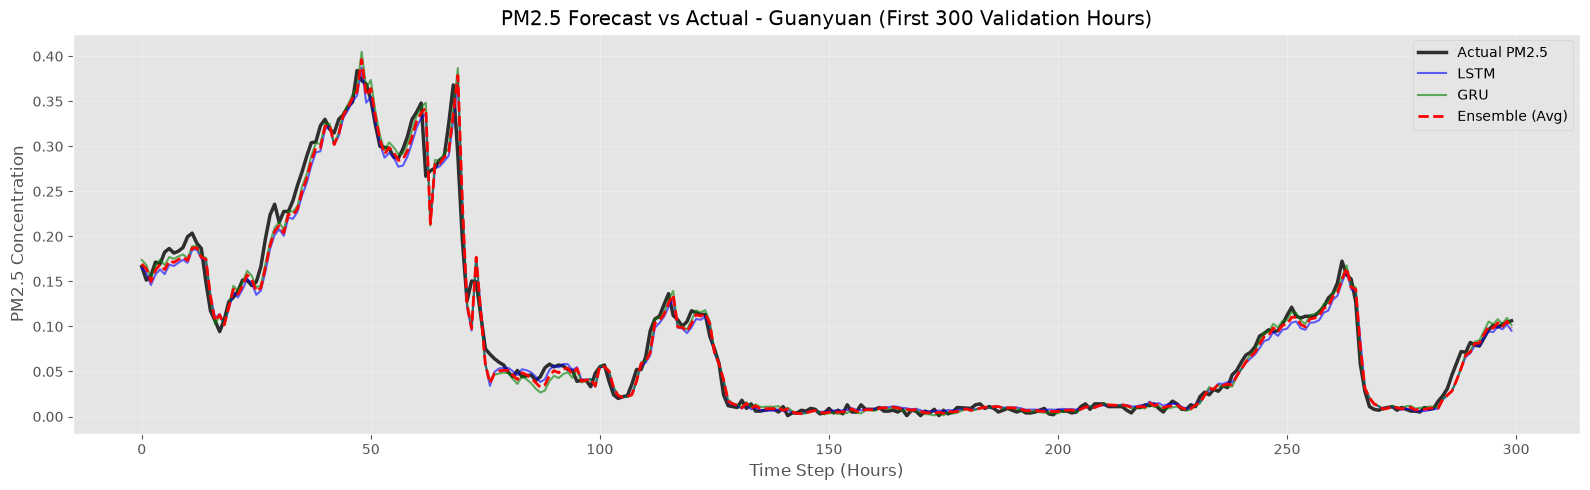

--------------------------------------------------
Station: Gucheng
  LSTM RMSE:     0.0188
  GRU RMSE:      0.0181
  Ensemble RMSE: 0.0182
--------------------------------------------------


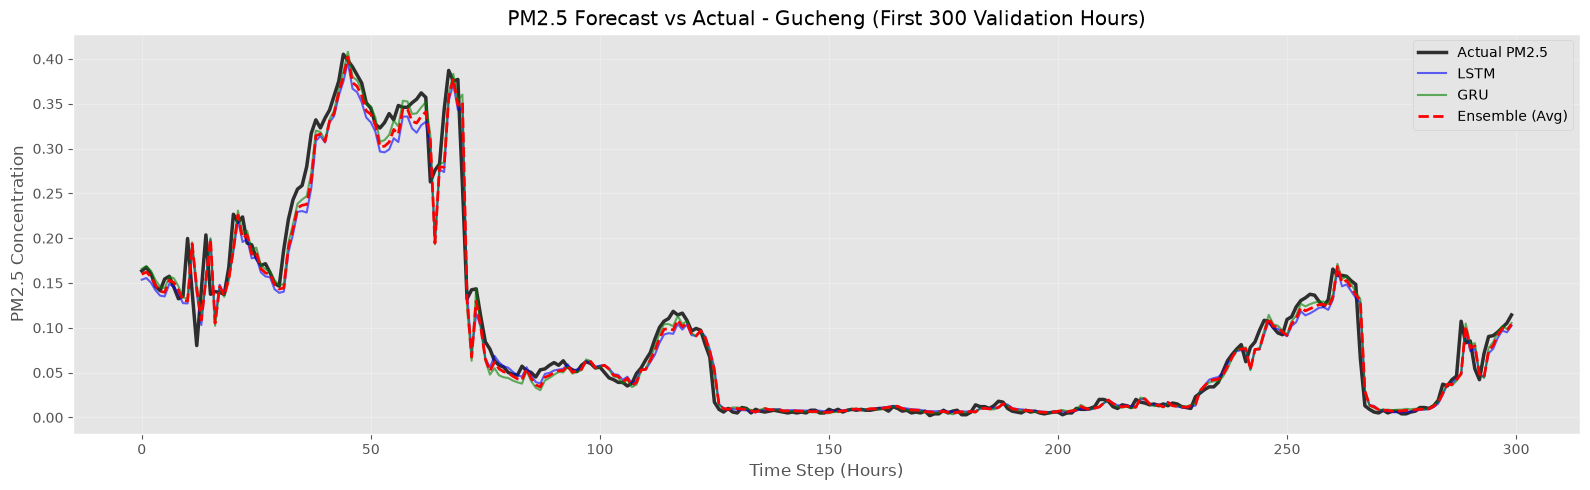

--------------------------------------------------
Station: Huairou
  LSTM RMSE:     0.0161
  GRU RMSE:      0.0162
  Ensemble RMSE: 0.0160
--------------------------------------------------


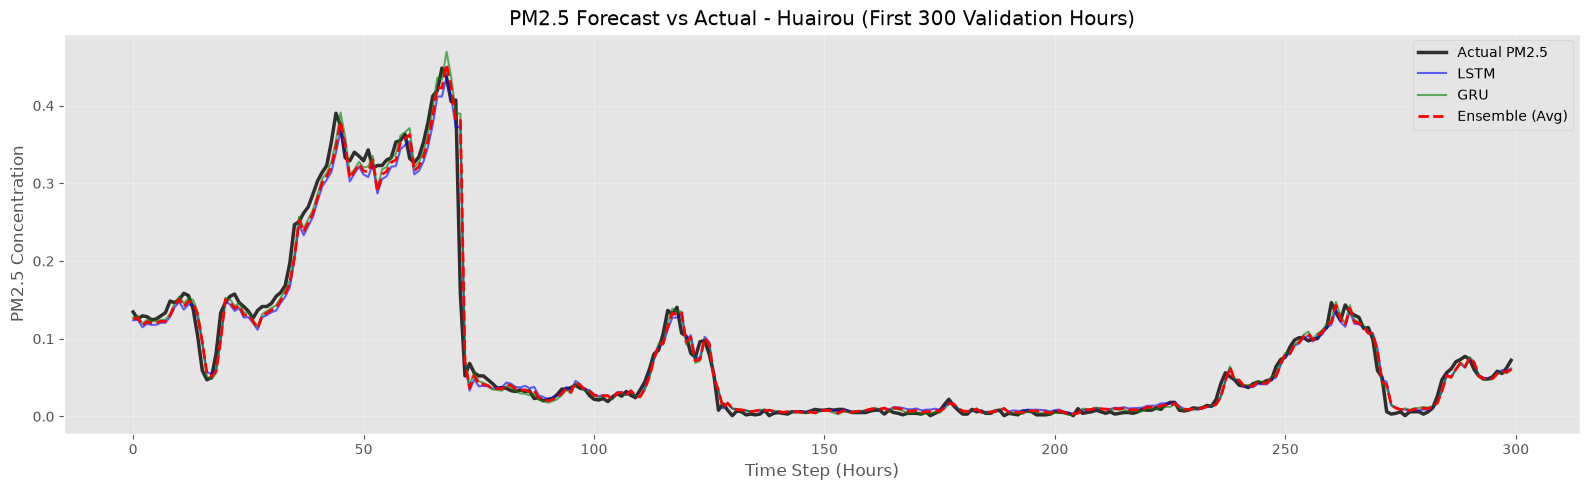

--------------------------------------------------
Station: Nongzhanguan
  LSTM RMSE:     0.0174
  GRU RMSE:      0.0171
  Ensemble RMSE: 0.0170
--------------------------------------------------


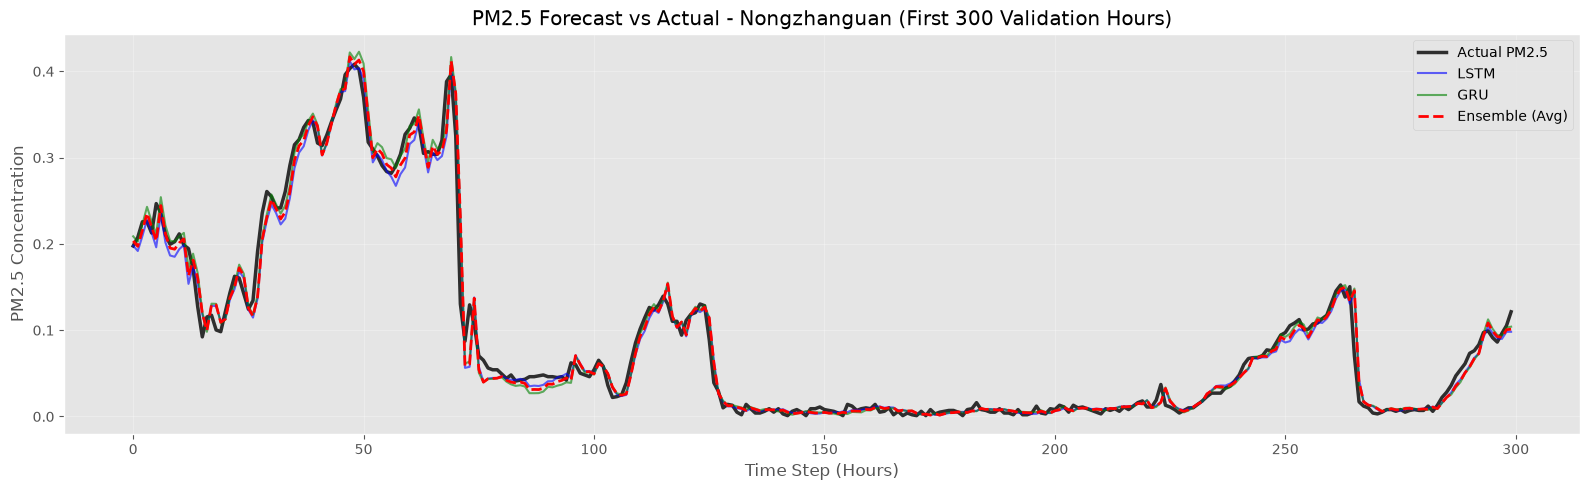

--------------------------------------------------
Station: Shunyi
  LSTM RMSE:     0.0177
  GRU RMSE:      0.0174
  Ensemble RMSE: 0.0173
--------------------------------------------------


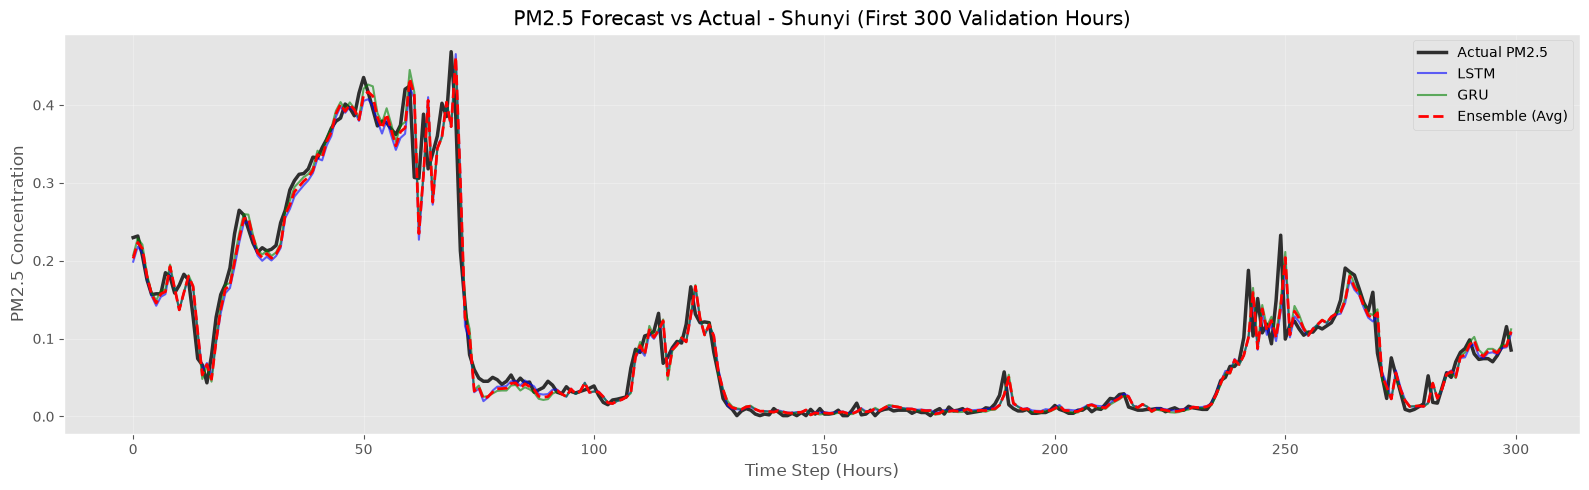

--------------------------------------------------
Station: Tiantan
  LSTM RMSE:     0.0158
  GRU RMSE:      0.0159
  Ensemble RMSE: 0.0157
--------------------------------------------------


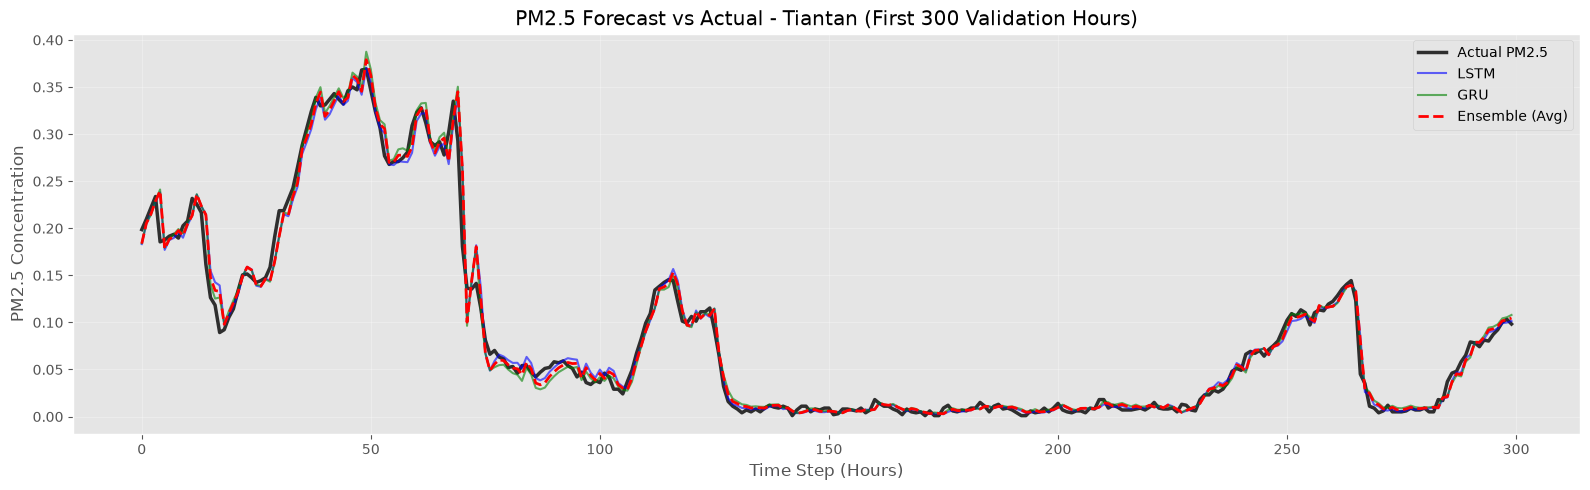

--------------------------------------------------
Station: Wanliu
  LSTM RMSE:     0.0164
  GRU RMSE:      0.0164
  Ensemble RMSE: 0.0163
--------------------------------------------------


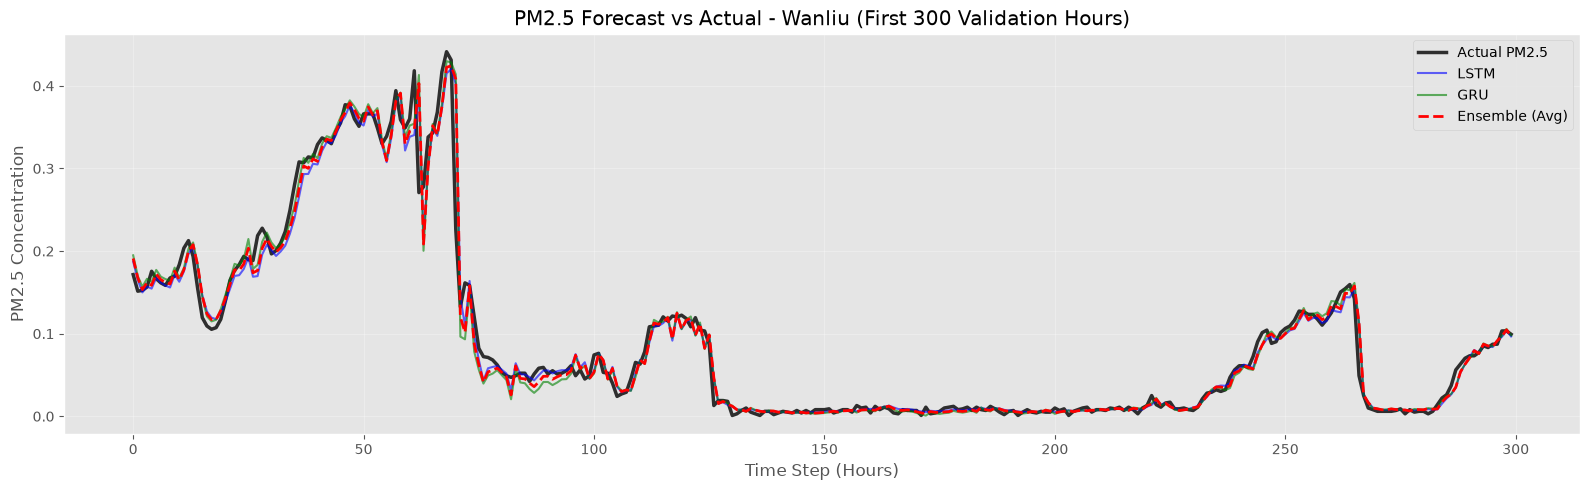

--------------------------------------------------
Station: Wanshouxigong
  LSTM RMSE:     0.0198
  GRU RMSE:      0.0196
  Ensemble RMSE: 0.0195
--------------------------------------------------


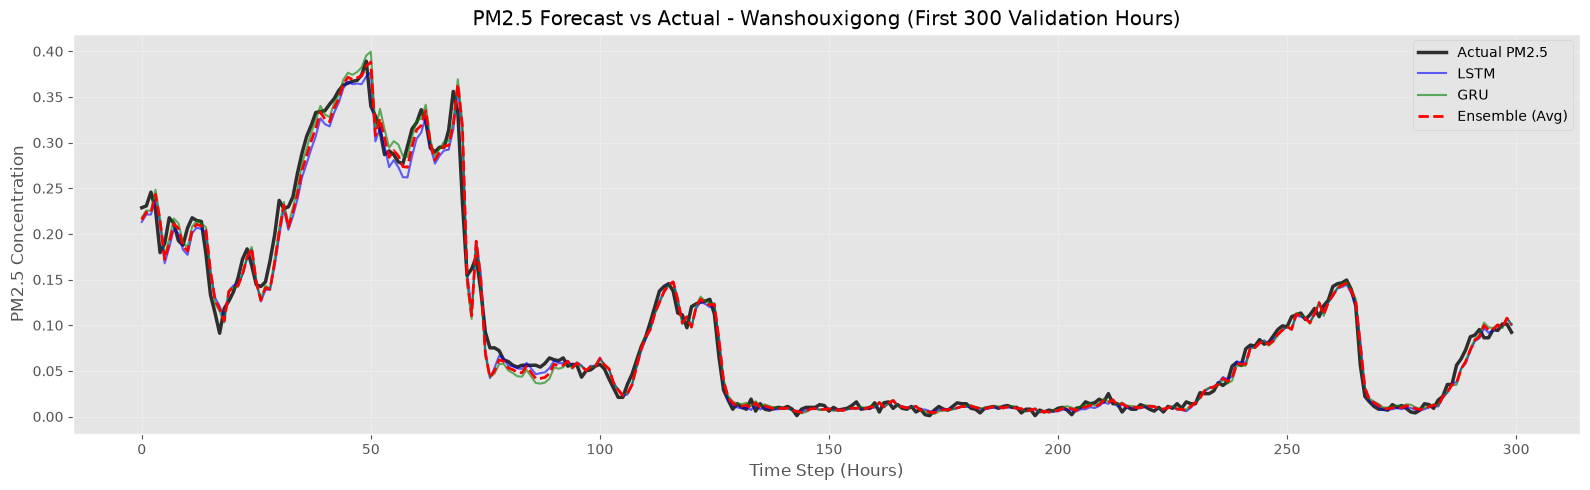

In [34]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Map the flat prediction arrays back to individual stations
# Since sequences were generated by iterating through val_df.groupby('station'), 
# we can count the sequences per station to find their exact start and end indices.
station_indices = {}
current_idx = 0

for station_name, group in val_df.groupby('station'):
    num_sequences = len(group) - window_size
    if num_sequences > 0:
        station_indices[station_name] = (current_idx, current_idx + num_sequences)
        current_idx += num_sequences

# 2. Iterate through each station, calculate metrics, and plot
plot_window = 300  # Plotting the first 300 points per station so the lines are readable

for station_name, (start_idx, end_idx) in station_indices.items():
    # Slice the predictions and actuals for the current station
    y_actual_station = y_val_actual[start_idx:end_idx]
    y_lstm_station = lstm_preds[start_idx:end_idx]
    y_gru_station = gru_preds[start_idx:end_idx]
    y_ens_station = ensemble_preds[start_idx:end_idx]
    
    # Calculate RMSE for the entire validation period of this station
    rmse_lstm = np.sqrt(mean_squared_error(y_actual_station, y_lstm_station))
    rmse_gru = np.sqrt(mean_squared_error(y_actual_station, y_gru_station))
    rmse_ens = np.sqrt(mean_squared_error(y_actual_station, y_ens_station))
    
    # Print the RMSE scores for the station
    print("-" * 50)
    print(f"Station: {station_name}")
    print(f"  LSTM RMSE:     {rmse_lstm:.4f}")
    print(f"  GRU RMSE:      {rmse_gru:.4f}")
    print(f"  Ensemble RMSE: {rmse_ens:.4f}")
    print("-" * 50)
    
    # Generate the plot
    plt.figure(figsize=(16, 5))
    
    # Plotting actuals and all three predictions with distinct colors
    plt.plot(y_actual_station[:plot_window], label='Actual PM2.5', color='black', linewidth=2.5, alpha=0.8)
    plt.plot(y_lstm_station[:plot_window], label='LSTM', color='blue', alpha=0.6, linewidth=1.5)
    plt.plot(y_gru_station[:plot_window], label='GRU', color='green', alpha=0.6, linewidth=1.5)
    plt.plot(y_ens_station[:plot_window], label='Ensemble (Avg)', color='red', linestyle='--', linewidth=2)
    
    plt.title(f'PM2.5 Forecast vs Actual - {station_name} (First {plot_window} Validation Hours)')
    plt.xlabel('Time Step (Hours)')
    plt.ylabel('PM2.5 Concentration')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [40]:
import pandas as pd
import numpy as np

# 1. Load the Kaggle test data
test_kaggle = pd.read_csv('test.csv')
raw_cols = ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

# 2. Un-flatten into a long-format DataFrame (24 rows per test window)
print("Un-flattening test data...")
records = []
for idx, row in test_kaggle.iterrows():
    window_id = row['id']
    station_name = row['station']
    
    # Extract values for each time step in the window (lag_24 is oldest -> step 0)
    for step, lag in enumerate(range(24, 0, -1)):
        record = {
            'row_idx': idx,
            'step_idx': step,
            'id': window_id,
            'station': station_name
        }
        for col in raw_cols:
            col_name = f"{col}_lag_{lag}"
            # Safe extraction in case some columns are missing
            record[col] = row[col_name] if col_name in test_kaggle.columns else np.nan
        records.append(record)

long_test_df = pd.DataFrame(records)

# 3. Impute Missing Values (strictly isolated within each 24-hour window)
print("Imputing missing values...")
def impute_test_window(group):
    # Numeric interpolation
    num_cols = group.select_dtypes(include=[np.number]).columns
    group[num_cols] = group[num_cols].interpolate(method='linear', limit_direction='forward').bfill().ffill()
    # Categorical fill
    group['wd'] = group['wd'].ffill().bfill()
    return group

long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(impute_test_window)

# 5. Scale the features utilizing the exact same feature_scaler fitted during training
print("Scaling features...")
long_test_df[all_features] = feature_scaler.transform(long_test_df[all_features])

# 6. Re-shape back to 3D Tensor (4103 sequences, 24 timesteps, N features)
# Sorting ensures the tensor perfectly aligns with the original Kaggle test_csv index 
long_test_df = long_test_df.sort_values(by=['row_idx', 'step_idx'])
X_test_submission = long_test_df[all_features].values.reshape(len(test_kaggle), 24, len(all_features))

# 7. Generate Predictions
print("Running inferences...")
lstm_preds_test_scaled = lstm_model.predict(X_test_submission, batch_size=256)
gru_preds_test_scaled = gru_model.predict(X_test_submission, batch_size=256)
ensemble_preds_test_scaled = (lstm_preds_test_scaled + gru_preds_test_scaled) / 2.0

# 8. Inverse Transform back to raw PM2.5 scale
lstm_preds_final = target_scaler.inverse_transform(lstm_preds_test_scaled).flatten()
gru_preds_final = target_scaler.inverse_transform(gru_preds_test_scaled).flatten()
ensemble_preds_final = target_scaler.inverse_transform(ensemble_preds_test_scaled).flatten()

# 9. Build Kaggle-compliant CSVs
print("Saving CSVs...")
sub_lstm = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': lstm_preds_final})
sub_gru = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': gru_preds_final})
sub_ens = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': ensemble_preds_final})

sub_lstm.to_csv('submission_lstm.csv', index=False)
sub_gru.to_csv('submission_gru.csv', index=False)
sub_ens.to_csv('submission_ensemble.csv', index=False)

print("\nDone! 3 Kaggle-ready files generated:")
print("- submission_lstm.csv")
print("- submission_gru.csv")
print("- submission_ensemble.csv")

Un-flattening test data...
Imputing missing values...
Scaling features...


KeyError: "['PM25_lag_1', 'PM25_lag_2', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24', 'PM25_roll_mean_3', 'PM25_roll_std_3', 'PM25_roll_mean_6', 'PM25_roll_std_6', 'PM25_roll_mean_12', 'PM25_roll_std_12', 'PM25_roll_mean_24', 'PM25_roll_std_24', 'PM25_diff1', 'PM25_diff24', 'wd_sin', 'wd_cos', 'station_Aotizhongxin', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos'] not in index"

In [43]:
import pandas as pd
import numpy as np

# Make sure your previously defined lists are active
lags = [1, 2, 3, 6, 12, 24]
windows = [3, 6, 12, 24]

# 1. Load the Kaggle test data
test_kaggle = pd.read_csv('test.csv')
raw_cols = ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

# 2. Un-flatten into long-format (24 rows per window)
print("Un-flattening test data...")
records = []
for idx, row in test_kaggle.iterrows():
    window_id = row['id']
    station_name = row['station']
    for step, lag in enumerate(range(24, 0, -1)):
        record = {'row_idx': idx, 'step_idx': step, 'id': window_id, 'station': station_name}
        for col in raw_cols:
            col_name = f"{col}_lag_{lag}"
            record[col] = row[col_name] if col_name in test_kaggle.columns else np.nan
        records.append(record)

long_test_df = pd.DataFrame(records)

# 3. Impute Missing Values in raw columns
def impute_test_window(group):
    num_cols = group.select_dtypes(include=[np.number]).columns
    # Interpolate in both directions to ensure no NaNs remain
    group[num_cols] = group[num_cols].interpolate(method='linear', limit_direction='both').ffill().bfill()
    group['wd'] = group['wd'].ffill().bfill()
    return group

long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(impute_test_window)

# 4. Feature Engineering (WITH PADDING to fix the 0.0 values issue)
# We pad the 24h window by repeating the first row so that lag_24 doesn't return pure NaNs
def engineer_test_features(group):
    # Pad by prepending the first row 24 times
    first_row = group.iloc[[0]].copy()
    padding = pd.concat([first_row] * 24, ignore_index=True)
    extended_group = pd.concat([padding, group], ignore_index=True)
    
    # Calculate features on the padded sequence
    for lag in lags:
        extended_group[f'PM25_lag_{lag}'] = extended_group['PM2.5'].shift(lag)
        
    for w in windows:
        extended_group[f'PM25_roll_mean_{w}'] = extended_group['PM2.5'].rolling(window=w).mean()
        extended_group[f'PM25_roll_std_{w}'] = extended_group['PM2.5'].rolling(window=w).std()
        
    extended_group['PM25_diff1'] = extended_group['PM2.5'].diff(1)
    extended_group['PM25_diff24'] = extended_group['PM2.5'].diff(24)
    
    # Fill any remaining NaNs at the very top of the padding
    extended_group = extended_group.bfill()
    
    # Return ONLY the actual 24 rows we care about (dropping the padding)
    return extended_group.iloc[24:]

print("Applying feature engineering...")
long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(engineer_test_features).reset_index(drop=True)

# 5. Cyclical Time & Station Encoding
long_test_df['hour_sin'] = np.sin(2 * np.pi * long_test_df['hour'] / 23)
long_test_df['hour_cos'] = np.cos(2 * np.pi * long_test_df['hour'] / 23)

long_test_df['month_sin'] = np.sin(2 * np.pi * long_test_df['month'] / 12)
long_test_df['month_cos'] = np.cos(2 * np.pi * long_test_df['month'] / 12)

long_test_df['date'] = pd.to_datetime(long_test_df[['year', 'month', 'day', 'hour']])
long_test_df['weekday'] = long_test_df['date'].dt.weekday

long_test_df['weekday_sin'] = np.sin(2 * np.pi * long_test_df['weekday'] / 7)
long_test_df['weekday_cos'] = np.cos(2 * np.pi * long_test_df['weekday'] / 7)

long_test_df['wd_angle'] = long_test_df['wd'].map(wd_map).fillna(0)
long_test_df['wd_sin'] = np.sin(np.radians(long_test_df['wd_angle']))
long_test_df['wd_cos'] = np.cos(np.radians(long_test_df['wd_angle']))

for st_col in station_cols:
    st_name = st_col.replace('station_', '')
    long_test_df[st_col] = (long_test_df['station'] == st_name).astype(float)

# 6. Scale Features & Reshape
print("Checking for remaining NaNs...")
nan_count = long_test_df[all_features].isna().sum().sum()
if nan_count > 0:
    print(f"Found {nan_count} NaNs! (Likely from entirely missing sensor windows). Filling with 0...")
    # Fill remaining NaNs with 0 (a safe fallback before scaling)
    long_test_df[all_features] = long_test_df[all_features].fillna(0)

print("Scaling features...")
long_test_df[all_features] = feature_scaler.transform(long_test_df[all_features])
long_test_df = long_test_df.sort_values(by=['row_idx', 'step_idx'])

# Recreate the 3D tensor for the LSTM/GRU models
X_test_submission = long_test_df[all_features].values.reshape(len(test_kaggle), 24, len(all_features))

# Recreate the 3D tensor for the LSTM/GRU models
X_test_submission = long_test_df[all_features].values.reshape(len(test_kaggle), 24, len(all_features))

# 7. Generate Scaled Predictions
print("Running inferences...")
lstm_preds_test_scaled = lstm_model.predict(X_test_submission, batch_size=256)
gru_preds_test_scaled = gru_model.predict(X_test_submission, batch_size=256)
ensemble_preds_test_scaled = (lstm_preds_test_scaled + gru_preds_test_scaled) / 2.0

# 8. Inverse Transform Back to Raw PM2.5 Scale using the correct feature_scaler
print("Reversing the scaling using original feature bounds...")

# Find exactly where PM2.5 is in the feature scaler's memory
pm25_idx = all_features.index('PM2.5')
pm25_min = feature_scaler.data_min_[pm25_idx]
pm25_max = feature_scaler.data_max_[pm25_idx]
pm25_range = pm25_max - pm25_min

# Manually apply the inverse transformation formula: X_raw = (X_scaled * Range) + Min
lstm_preds_final = (lstm_preds_test_scaled.flatten() * pm25_range) + pm25_min
gru_preds_final = (gru_preds_test_scaled.flatten() * pm25_range) + pm25_min
ensemble_preds_final = (ensemble_preds_test_scaled.flatten() * pm25_range) + pm25_min

# Sanity Check print out
print("\n--- Sanity Check ---")
print(f"Scaled LSTM predictions (first 3): {lstm_preds_test_scaled[:3].flatten()}")
print(f"Inverse Transformed PM2.5 (first 3): {lstm_preds_final[:3]}")
print("--------------------\n")

# 9. Build Kaggle-compliant CSVs
print("Saving CSVs...")
sub_lstm = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': lstm_preds_final})
sub_gru = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': gru_preds_final})
sub_ens = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': ensemble_preds_final})

sub_lstm.to_csv('submission_lstm.csv', index=False)
sub_gru.to_csv('submission_gru.csv', index=False)
sub_ens.to_csv('submission_ensemble.csv', index=False)

print("Done! The 3 CSV files have been properly un-scaled and saved.")

Un-flattening test data...
Applying feature engineering...
Checking for remaining NaNs...
Found 1056 NaNs! (Likely from entirely missing sensor windows). Filling with 0...
Scaling features...
Running inferences...
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Reversing the scaling using original feature bounds...

--- Sanity Check ---
Scaled LSTM predictions (first 3): [0.18032712 0.15785795 0.40912658]
Inverse Transformed PM2.5 (first 3): [181.78613609 159.38438064 409.89920002]
--------------------

Saving CSVs...
Done! The 3 CSV files have been properly un-scaled and saved.


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ===============================
# Prepare Test Sequences
# ===============================

# Use original unscaled merged df
test_part = df[df['date'] >= split_date].copy()

# Need previous 72 hours from training to avoid dropping the first 72 test predictions
history_part = df[df['date'] < split_date].copy()
history_tails = history_part.groupby('station').tail(window_size)

# Concat AND strictly sort by station and date to prevent sequence scrambling
test_input = pd.concat([history_tails, test_part], axis=0)
test_input = test_input.sort_values(by=['station', 'date']).reset_index(drop=True)

# Apply same scaling used during training
test_input[all_features] = feature_scaler.transform(test_input[all_features])
test_input['PM2.5_scaled'] = target_scaler.transform(test_input[['PM2.5']])

# Create sequences
X_test, y_test_scaled = create_sequences_per_station(
    test_input,
    feature_cols=all_features,
    target_col='PM2.5_scaled',
    window_size=window_size
)

print("Test shape:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test_scaled.shape}")

# ===============================
# Predict
# ===============================

y_pred_scaled = lstm_model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

# ===============================
# Inverse Scaling
# ===============================

# Reshape y_test_scaled to 2D array for the scaler
y_test_raw = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
y_pred_raw = target_scaler.inverse_transform(y_pred_scaled)

# ===============================
# Metrics
# ===============================

rmse_lstm_val_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_lstm_val_raw = mean_absolute_error(y_test_raw, y_pred_raw)

print(f"Validation LSTM RMSE (vs Raw): {rmse_lstm_val_raw:.4f}")
print(f"Validation LSTM MAE (vs Raw): {mae_lstm_val_raw:.4f}")

Test shape:
X_test: (105120, 24, 43)
y_test: (105120,)
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Validation LSTM RMSE (vs Raw): 0.02
Validation LSTM MAE (vs Raw): 0.01


        station                date  Actual_PM25  Predicted_PM25
0  Aotizhongxin 2016-03-01 00:00:00     0.061184        0.064982
1  Aotizhongxin 2016-03-01 01:00:00     0.075226        0.063807
2  Aotizhongxin 2016-03-01 02:00:00     0.083250        0.079633
3  Aotizhongxin 2016-03-01 03:00:00     0.092277        0.085989
4  Aotizhongxin 2016-03-01 04:00:00     0.117352        0.101373


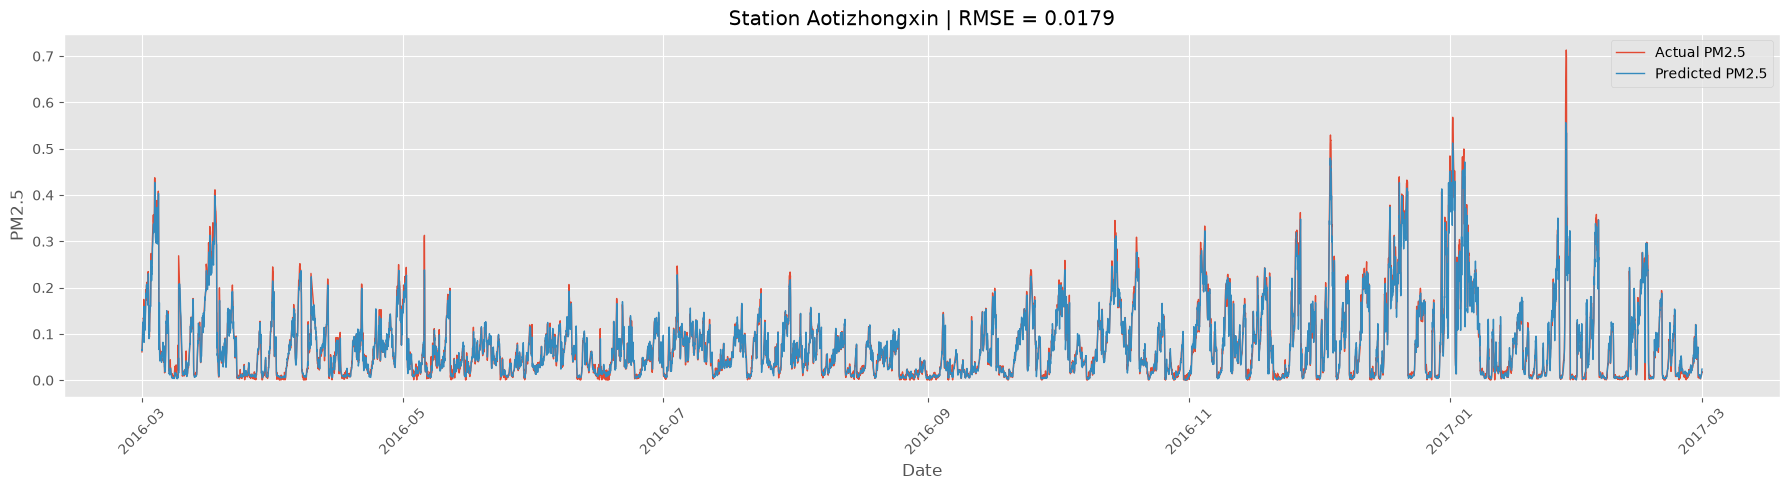

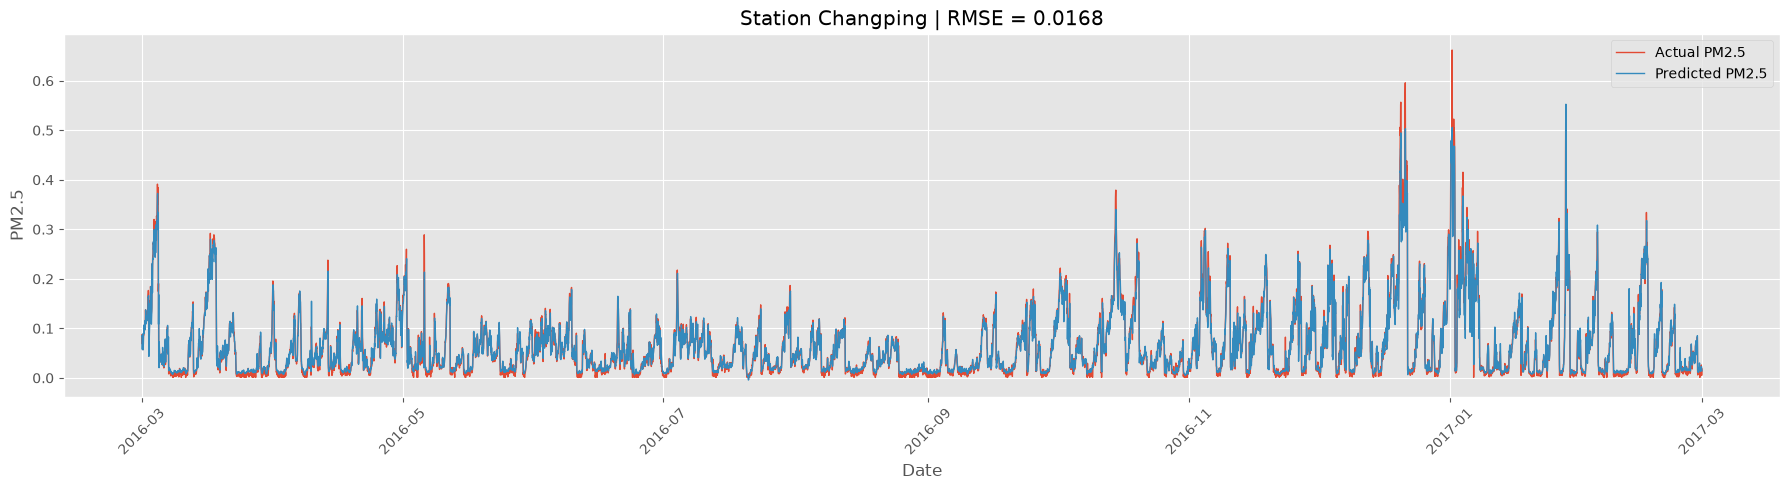

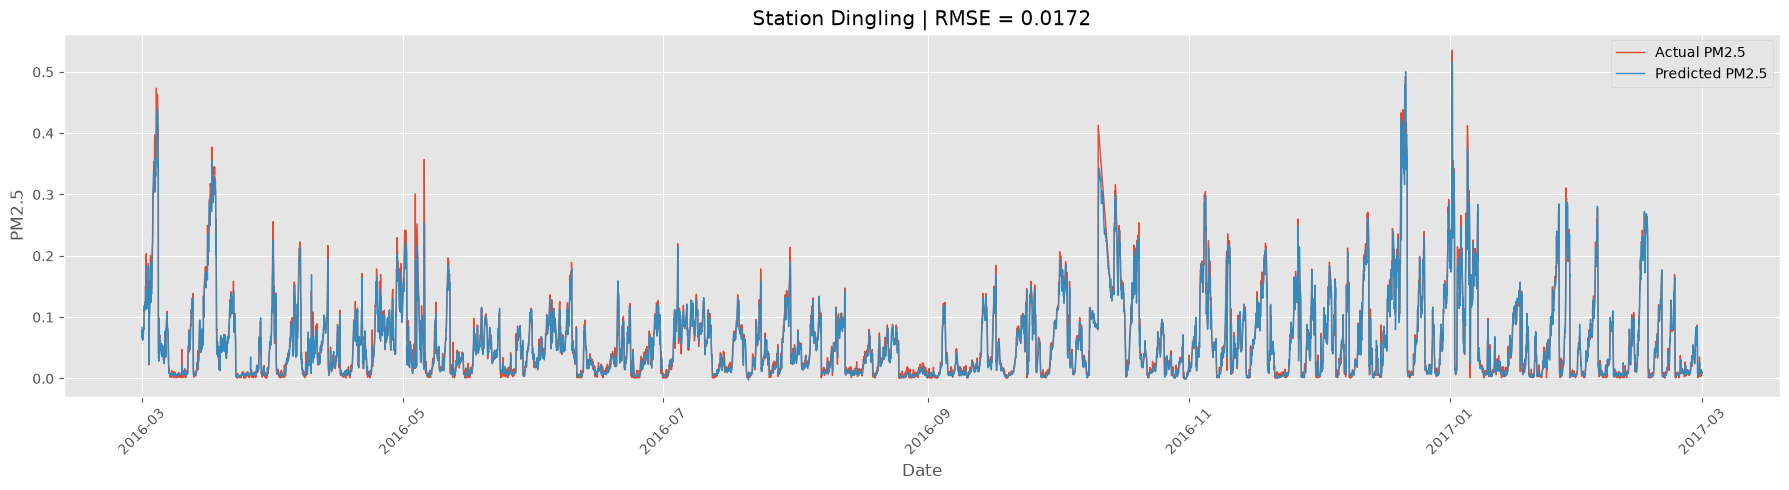

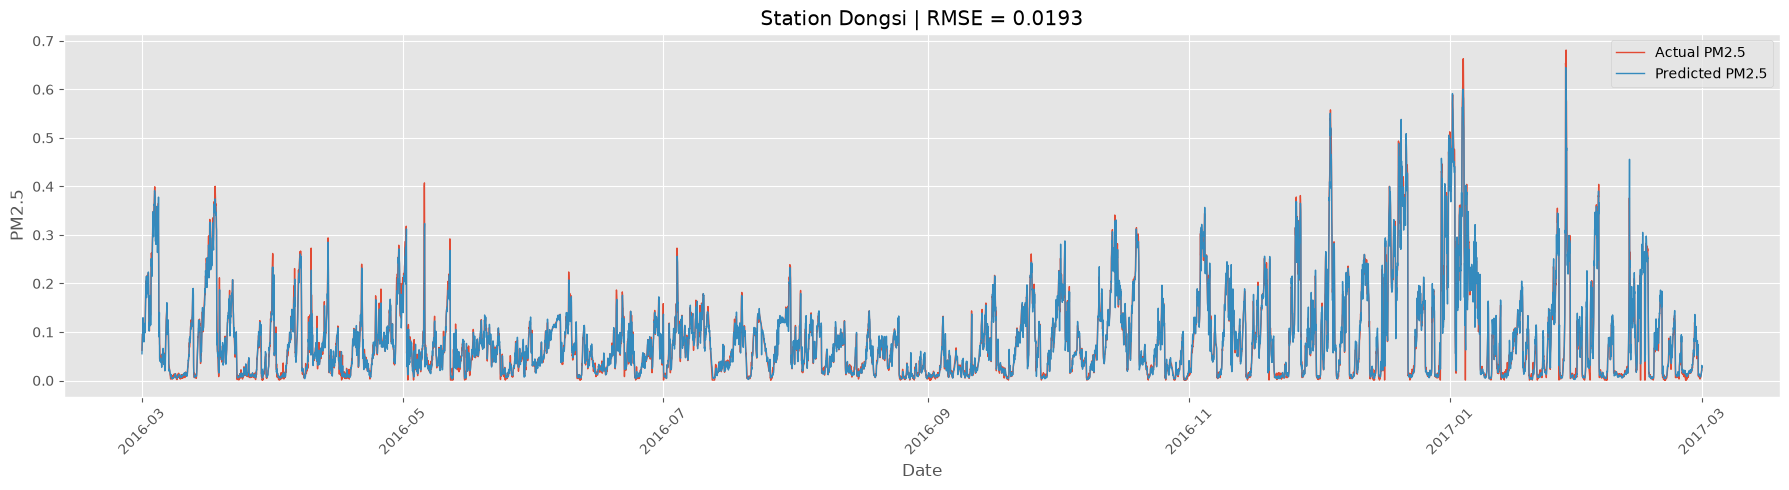

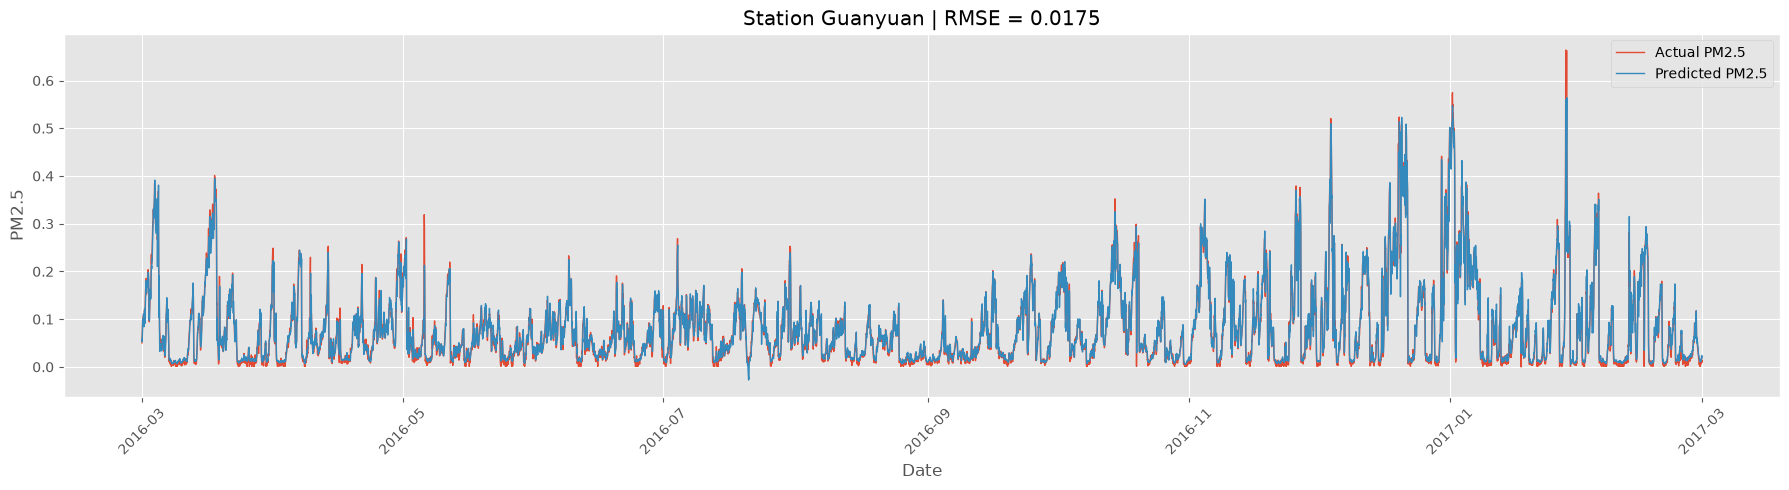

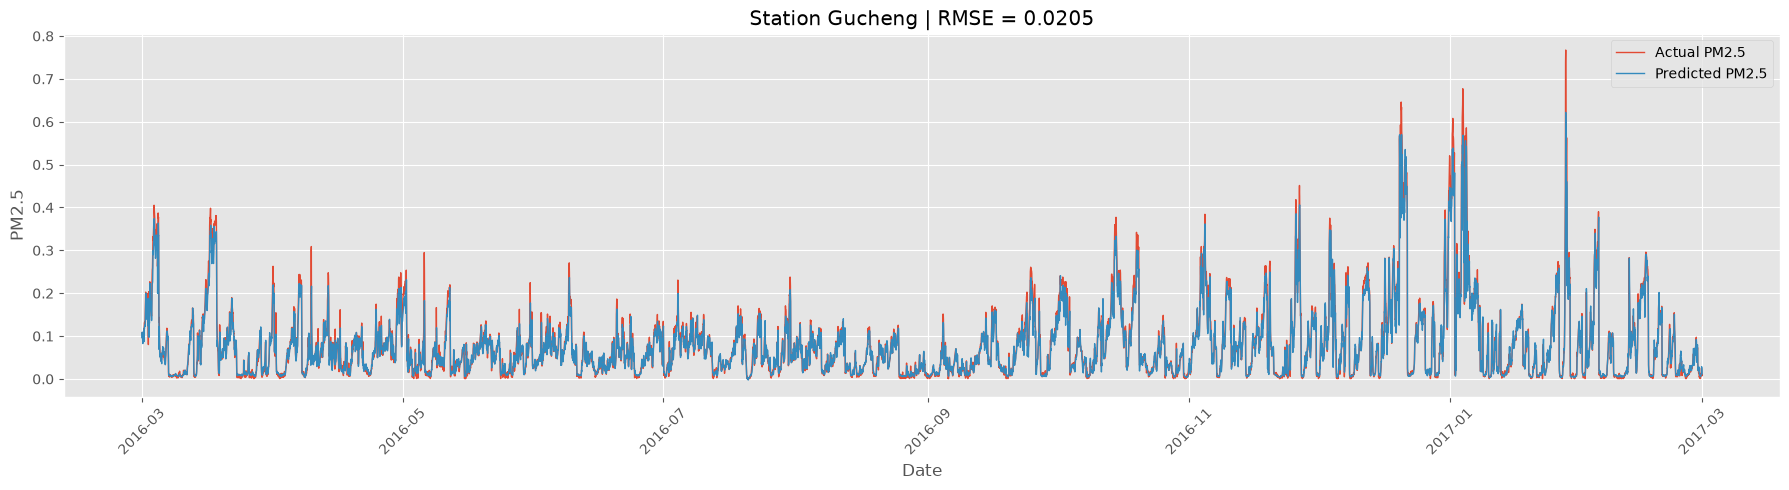

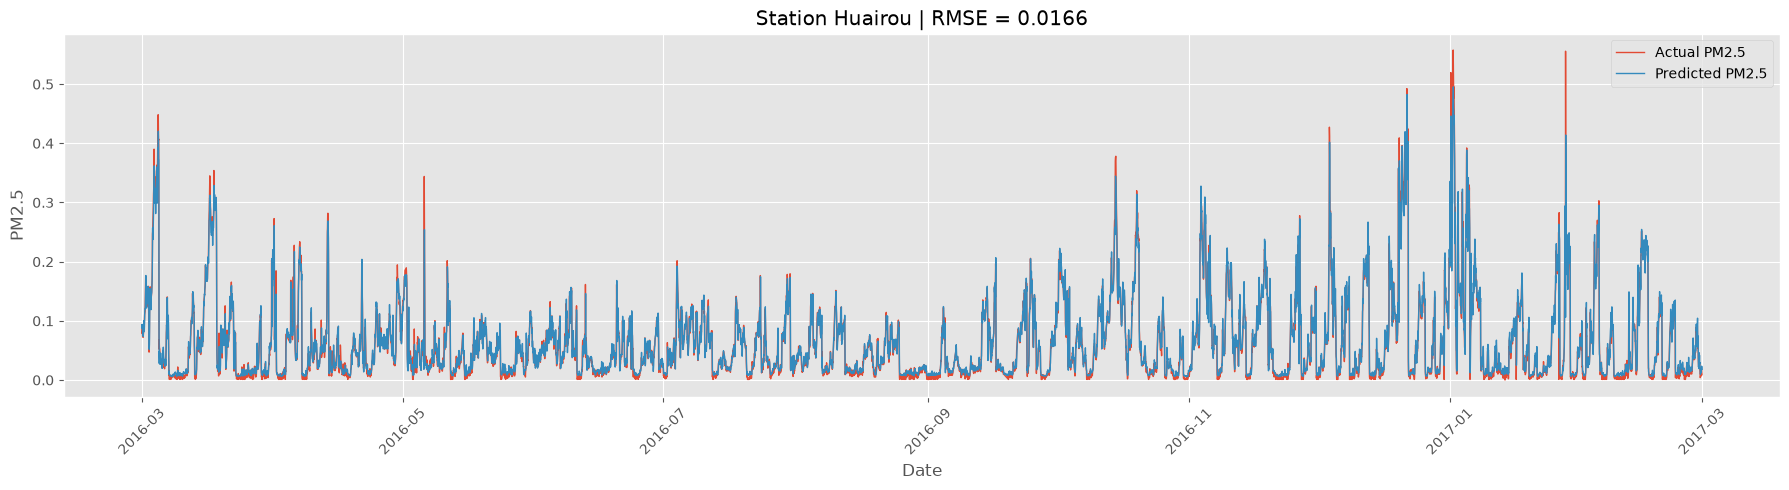

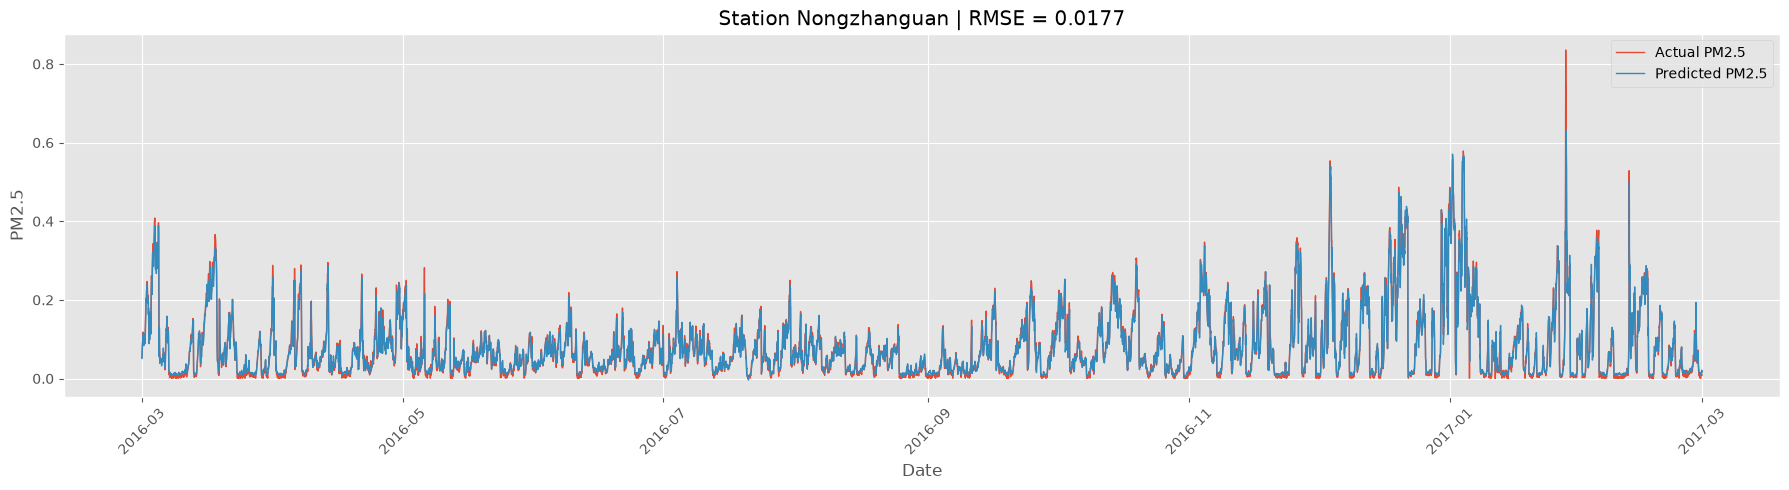

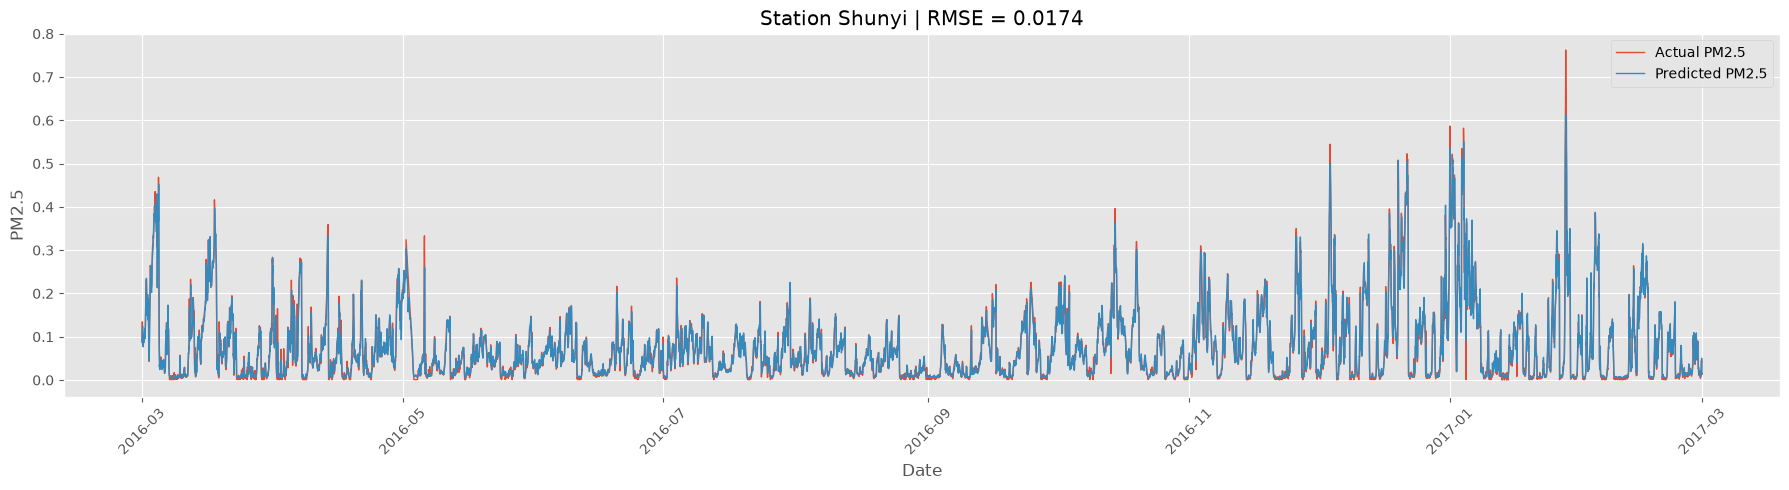

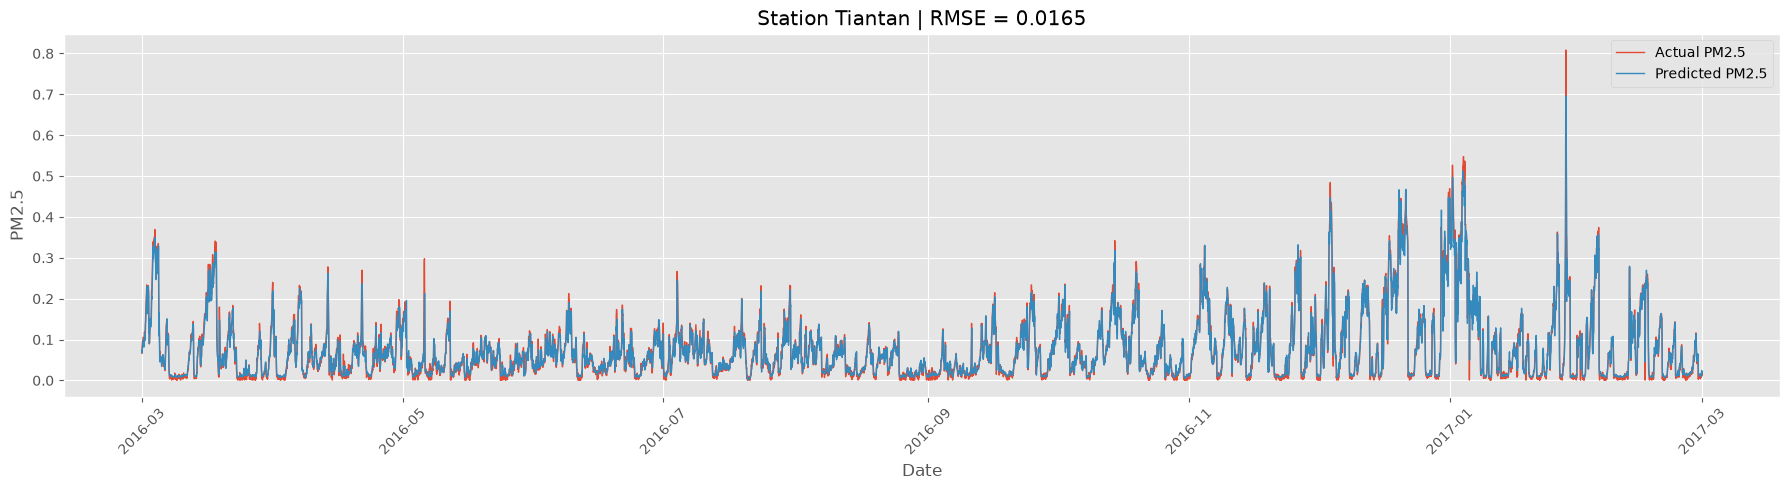

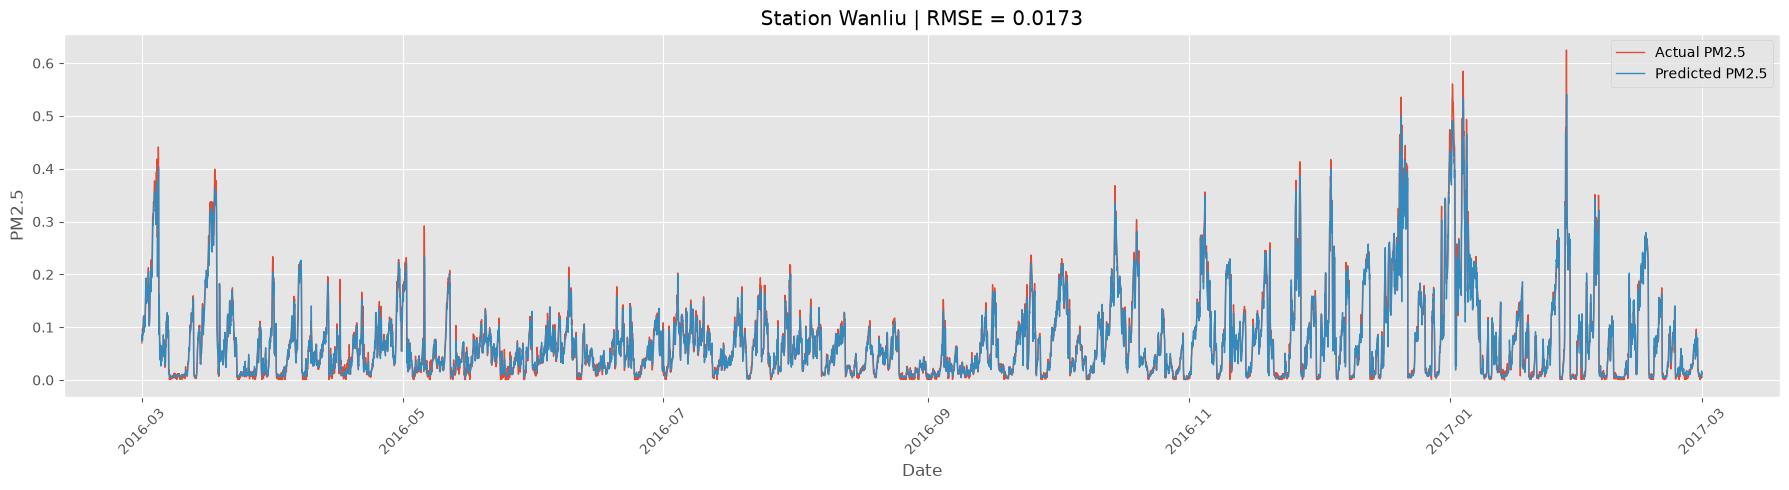

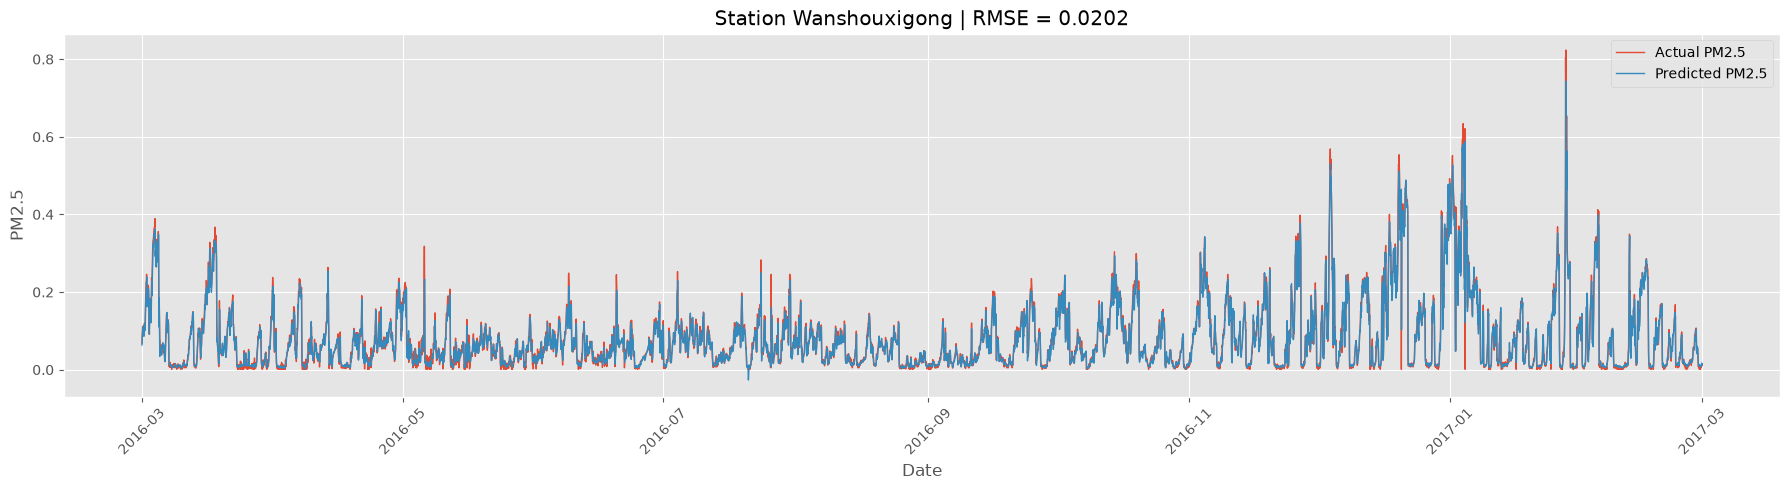


RMSE per station
----------------
Aotizhongxin: 0.0179
Changping: 0.0168
Dingling: 0.0172
Dongsi: 0.0193
Guanyuan: 0.0175
Gucheng: 0.0205
Huairou: 0.0166
Nongzhanguan: 0.0177
Shunyi: 0.0174
Tiantan: 0.0165
Wanliu: 0.0173
Wanshouxigong: 0.0202


In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd


# ============================================
# Create prediction dataframe with dates/stations
# ============================================

# Create test sequence metadata
def create_test_metadata(data, window_size=72):
    meta = []

    for station_name, group in data.groupby('station'):

        # Only keep prediction points (after window)
        dates = group['date'].values[window_size:]

        for d in dates:
            meta.append([
                station_name,
                d
            ])

    return pd.DataFrame(
        meta,
        columns=['station','date']
    )


# Use the same test_input used for X_test generation
test_meta = create_test_metadata(
    test_input,
    window_size
)


# Add predictions
results = test_meta.copy()

results['Actual_PM25'] = y_test_raw.flatten()
results['Predicted_PM25'] = y_pred_raw.flatten()


# Sort
results = results.sort_values(
    ['station','date']
)


print(results.head())



# ============================================
# Plot every station
# ============================================

stations = results['station'].unique()

station_rmse = {}


for station in stations:

    station_data = results[
        results['station'] == station
    ].copy()


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            station_data['Actual_PM25'],
            station_data['Predicted_PM25']
        )
    )

    station_rmse[station] = rmse


    # Plot
    plt.figure(figsize=(18,5))

    plt.plot(
        station_data['date'],
        station_data['Actual_PM25'],
        label='Actual PM2.5',
        linewidth=1
    )

    plt.plot(
        station_data['date'],
        station_data['Predicted_PM25'],
        label='Predicted PM2.5',
        linewidth=1
    )


    plt.title(
        f"Station {station} | RMSE = {rmse:.4f}"
    )

    plt.xlabel("Date")
    plt.ylabel("PM2.5")

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()



# ============================================
# Print RMSE table
# ============================================

print("\nRMSE per station")
print("----------------")

for station, rmse in station_rmse.items():
    print(
        f"{station}: {rmse:.4f}"
    )

In [37]:
import pandas as pd
import numpy as np

# Make sure your previously defined lists are active
lags = [1, 2, 3, 6, 12, 24]
windows = [3, 6, 12, 24]

# 1. Load the Kaggle test data
test_kaggle = pd.read_csv('test.csv')
raw_cols = ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

# 2. Un-flatten into long-format (24 rows per window)
print("Un-flattening test data...")
records = []
for idx, row in test_kaggle.iterrows():
    window_id = row['id']
    station_name = row['station']
    for step, lag in enumerate(range(24, 0, -1)):
        record = {'row_idx': idx, 'step_idx': step, 'id': window_id, 'station': station_name}
        for col in raw_cols:
            col_name = f"{col}_lag_{lag}"
            record[col] = row[col_name] if col_name in test_kaggle.columns else np.nan
        records.append(record)

long_test_df = pd.DataFrame(records)

# 3. Impute Missing Values in raw columns
def impute_test_window(group):
    num_cols = group.select_dtypes(include=[np.number]).columns
    # Interpolate in both directions to ensure no NaNs remain
    group[num_cols] = group[num_cols].interpolate(method='linear', limit_direction='both').ffill().bfill()
    group['wd'] = group['wd'].ffill().bfill()
    return group

long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(impute_test_window)

# 4. Feature Engineering (WITH PADDING to fix the 0.0 values issue)
# We pad the 24h window by repeating the first row so that lag_24 doesn't return pure NaNs
def engineer_test_features(group):
    # Pad by prepending the first row 24 times
    first_row = group.iloc[[0]].copy()
    padding = pd.concat([first_row] * 24, ignore_index=True)
    extended_group = pd.concat([padding, group], ignore_index=True)
    
    # Calculate features on the padded sequence
    for lag in lags:
        extended_group[f'PM25_lag_{lag}'] = extended_group['PM2.5'].shift(lag)
        
    for w in windows:
        extended_group[f'PM25_roll_mean_{w}'] = extended_group['PM2.5'].rolling(window=w).mean()
        extended_group[f'PM25_roll_std_{w}'] = extended_group['PM2.5'].rolling(window=w).std()
        
    extended_group['PM25_diff1'] = extended_group['PM2.5'].diff(1)
    extended_group['PM25_diff24'] = extended_group['PM2.5'].diff(24)
    
    # Fill any remaining NaNs at the very top of the padding
    extended_group = extended_group.bfill()
    
    # Return ONLY the actual 24 rows we care about (dropping the padding)
    return extended_group.iloc[24:]

print("Applying feature engineering...")
long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(engineer_test_features).reset_index(drop=True)

# 5. Cyclical Time & Station Encoding
long_test_df['hour_sin'] = np.sin(2 * np.pi * long_test_df['hour'] / 23)
long_test_df['hour_cos'] = np.cos(2 * np.pi * long_test_df['hour'] / 23)

long_test_df['month_sin'] = np.sin(2 * np.pi * long_test_df['month'] / 12)
long_test_df['month_cos'] = np.cos(2 * np.pi * long_test_df['month'] / 12)

long_test_df['date'] = pd.to_datetime(long_test_df[['year', 'month', 'day', 'hour']])
long_test_df['weekday'] = long_test_df['date'].dt.weekday

long_test_df['weekday_sin'] = np.sin(2 * np.pi * long_test_df['weekday'] / 7)
long_test_df['weekday_cos'] = np.cos(2 * np.pi * long_test_df['weekday'] / 7)

long_test_df['wd_angle'] = long_test_df['wd'].map(wd_map).fillna(0)
long_test_df['wd_sin'] = np.sin(np.radians(long_test_df['wd_angle']))
long_test_df['wd_cos'] = np.cos(np.radians(long_test_df['wd_angle']))

for st_col in station_cols:
    st_name = st_col.replace('station_', '')
    long_test_df[st_col] = (long_test_df['station'] == st_name).astype(float)

# 6. Scale Features & Reshape
print("Scaling features...")
long_test_df[all_features] = feature_scaler.transform(long_test_df[all_features])
long_test_df = long_test_df.sort_values(by=['row_idx', 'step_idx'])

# Recreate the 3D tensor for the LSTM/GRU models
X_test_submission = long_test_df[all_features].values.reshape(len(test_kaggle), 24, len(all_features))

# 7. Generate Scaled Predictions
print("Running inferences...")
lstm_preds_test_scaled = lstm_model.predict(X_test_submission, batch_size=256)
gru_preds_test_scaled = gru_model.predict(X_test_submission, batch_size=256)
ensemble_preds_test_scaled = (lstm_preds_test_scaled + gru_preds_test_scaled) / 2.0

# 8. Inverse Transform Back to Raw PM2.5 Scale using the correct feature_scaler
print("Reversing the scaling using original feature bounds...")

# Find exactly where PM2.5 is in the feature scaler's memory
pm25_idx = all_features.index('PM2.5')
pm25_min = feature_scaler.data_min_[pm25_idx]
pm25_max = feature_scaler.data_max_[pm25_idx]
pm25_range = pm25_max - pm25_min

# Manually apply the inverse transformation formula: X_raw = (X_scaled * Range) + Min
lstm_preds_final = (lstm_preds_test_scaled.flatten() * pm25_range) + pm25_min
gru_preds_final = (gru_preds_test_scaled.flatten() * pm25_range) + pm25_min
ensemble_preds_final = (ensemble_preds_test_scaled.flatten() * pm25_range) + pm25_min

# Sanity Check print out
print("\n--- Sanity Check ---")
print(f"Scaled LSTM predictions (first 3): {lstm_preds_test_scaled[:3].flatten()}")
print(f"Inverse Transformed PM2.5 (first 3): {lstm_preds_final[:3]}")
print("--------------------\n")

# 9. Build Kaggle-compliant CSVs
print("Saving CSVs...")
sub_lstm = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': lstm_preds_final})
sub_gru = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': gru_preds_final})
sub_ens = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': ensemble_preds_final})

sub_lstm.to_csv('submission_lstm.csv', index=False)
sub_gru.to_csv('submission_gru.csv', index=False)
sub_ens.to_csv('submission_ensemble.csv', index=False)

print("Done! The 3 CSV files have been properly un-scaled and saved.")

Un-flattening test data...
Applying feature engineering...
Scaling features...
Running inferences...
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Reversing the scaling using original feature bounds...

--- Sanity Check ---
Scaled LSTM predictions (first 3): [0.18032712 0.15785795 0.40912658]
Inverse Transformed PM2.5 (first 3): [181.78613609 159.38438064 409.89920002]
--------------------

Saving CSVs...
Done! The 3 CSV files have been properly un-scaled and saved.


In [44]:
# Save trained models
lstm_model.save("lstm_pm25_model.keras")
gru_model.save("gru_pm25_model.keras")

print("Models saved successfully!")

Models saved successfully!
